In [1]:
import os
import random
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (Input, LSTM, RepeatVector, TimeDistributed, Dense, Embedding,Flatten,Concatenate,Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1788354475.059015    9848 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#Configuration for deterministic result

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()


In [3]:
#Load cleaned data for training

data = pd.read_csv('final_data.csv')
data.columns

Index(['name', 'SID', 'timestamp', 'visitors', 'avgDuration', 'weekday',
       'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos'],
      dtype='str')

In [4]:
# Training Configuration

continous_features = ['visitors']
cyclic_features = ['hour_sin','hour_cos','weekday_sin','weekday_cos']
features = continous_features + cyclic_features
n_features = len(features)
window_size = 24


reading_per_sensor = data.groupby(['SID'])['timestamp'].count().iloc[0]

#Split 2 days of data of each sensor for validation and rest for training
train_split = 1 - (48/reading_per_sensor)


In [5]:
# Order data by timestamp and SID

data['timestamp'] = pd.to_datetime(data['timestamp'])
data = data.sort_values(['SID','timestamp']).reset_index(drop = True)

print(data.dtypes)

name                                 str
SID                                  str
timestamp      datetime64[us, UTC+02:00]
visitors                         float64
avgDuration                      float64
weekday                            int64
hour_sin                         float64
hour_cos                         float64
weekday_sin                      float64
weekday_cos                      float64
dtype: object


In [6]:
#Creating a sliding Windows

#Split data of each sensor chronologically
# The data are scaled per sensor. Scaler per sensor is used later for anomaly detection

scalers = {}
windows, sensor_ids, timestamps,locations = [], [], [], []
train_windows, train_sensor_ids = [], []
val_windows, val_sensor_ids = [], []


for sensor in data['SID'].unique():
    sensor_data = data[data['SID'] == sensor].reset_index(drop = True)
    total_reading = len(sensor_data)

    total_train = int(total_reading * train_split)

    scaler = StandardScaler()
    scaler.fit(sensor_data.loc[:total_train-1,continous_features])
    scalers[sensor] = scaler

    sensor_data[continous_features] = scaler.transform(sensor_data[continous_features])

    values = sensor_data[features].values
    timestamp = sensor_data['timestamp']
    names = sensor_data['name'].values

    n_windows = total_reading - window_size +1
    train_window_count = total_train - window_size +1

    for i in range(n_windows):
        window = values[i:i+window_size]
        end_index = i +window_size-1

        windows.append(window)
        sensor_ids.append(sensor)
        timestamps.append(timestamp.iloc[end_index])
        locations.append(names[end_index])

        if i < train_window_count:
            train_windows.append(window)
            train_sensor_ids.append(sensor)
        else:
            val_windows.append(window)
            val_sensor_ids.append(sensor)
    


windows = np.array(windows)
train_windows = np.array(train_windows)
val_windows = np.array(val_windows)

sensor_ids = np.array(sensor_ids)
train_sensor_ids = np.array(train_sensor_ids)
val_sensor_ids = np.array(val_sensor_ids)

print(f"All windows:   {windows.shape}")
print(f"Train windows: {train_windows.shape}")
print(f"Val windows:   {val_windows.shape}")

All windows:   (8736, 24, 5)
Train windows: (7392, 24, 5)
Val windows:   (1344, 24, 5)


In [7]:
#Encode Sensors for sensor Embedding

encoder = LabelEncoder()
encoder.fit(sensor_ids)

sensor_ids_encoded = encoder.transform(sensor_ids).reshape(-1,1)
train_sensors_encoded = encoder.transform(train_sensor_ids).reshape(-1,1)
val_sensors_encoded = encoder.transform(val_sensor_ids).reshape(-1,1)


total_sensors = len(encoder.classes_)
print(f'Total Senors: {total_sensors}')
print(train_sensors_encoded.shape)

Total Senors: 28
(7392, 1)


In [8]:
#Plot the loss functions
def loss_function_analysis(history):
    history_dict = history.history
    train_loss = history_dict['loss']
    val_loss = history_dict.get('val_loss')
    epochs = range(1, len(train_loss) + 1)

    plt.plot(epochs, train_loss, label='Train Loss', color='black')
    plt.plot(epochs, val_loss, label='Validation Loss', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Function Analysis')
    plt.legend()
    plt.savefig('loss_function.png')
    plt.show()

In [9]:
NUM_SENSORS = total_sensors
EMBED_DIM = int(np.sqrt(NUM_SENSORS))

inputs = Input(shape=(window_size, n_features), name='Input_Layer')
sensor_input = Input(shape=(1,), dtype='int32', name='Sensor_ID_Input')

sensor_embed = Embedding(NUM_SENSORS, EMBED_DIM, name='sensor_embedding')(sensor_input)
sensor_embed = Flatten()(sensor_embed)                              
sensor_embed_seq = RepeatVector(window_size)(sensor_embed)         

x = Concatenate(axis=-1, name='concat_sensor_input')([inputs, sensor_embed_seq])

# ncoder
x = LSTM(64, return_sequences=True, name='encoder1')(x)
x = LSTM(32, return_sequences=False, name='encoder2')(x)


latent = Dense(16, activation='relu', name='latent')(x)
latent_dropped = Dropout(0.2)(latent)

# Decoder
x = RepeatVector(window_size)(latent_dropped)
x = LSTM(32, return_sequences=True, name='decoder1')(x)
x = LSTM(64, return_sequences=True, name='decoder2')(x)
outputs = TimeDistributed(Dense(n_features))(x)

model = keras.models.Model(inputs=[inputs, sensor_input], outputs=outputs)
model.summary()

I0000 00:00:1788354478.849048    9848 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4620 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Sensor_ID_Input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_embedding    │ (None, 1, 5)      │        140 │ Sensor_ID_Input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 5)         │          0 │ sensor_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Layer         │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 24, 5)     │          0 │ flatten[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_sensor_input │ (None, 24, 10)    │          0 │ Input_Layer[0][0… │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1 (LSTM)     │ (None, 24, 64)    │     19,200 │ concat_sensor_in… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder2 (LSTM)     │ (None, 32)        │     12,416 │ encoder1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent (Dense)      │ (None, 16)        │        528 │ encoder2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ latent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 24, 16)    │          0 │ dropout[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder1 (LSTM)     │ (None, 24, 32)    │      6,272 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder2 (LSTM)     │ (None, 24, 64)    │     24,832 │ decoder1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 24, 5)     │        325 │ decoder2[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 63,713 (248.88 KB)

 Trainable params: 63,713 (248.88 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#Compile model

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer = optimizer, loss = 'mse')

In [11]:
#Train Model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=1e-2,
    restore_best_weights=True
)

history = model.fit(
    [train_windows, train_sensors_encoded], train_windows,
    validation_data=([val_windows, val_sensors_encoded], val_windows),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    shuffle= False
)

Epoch 1/50


E0000 00:00:1788354480.130921    9848 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
I0000 00:00:1788354483.641435    9936 cuda_dnn.cc:461] Loaded cuDNN version 92300


116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.4091 - val_loss: 0.2622
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1738 - val_loss: 0.1777
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1429 - val_loss: 0.1557
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1313 - val_loss: 0.1445
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1239 - val_loss: 0.1380
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1159 - val_loss: 0.1300
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1115 - val_loss: 0.1267
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1087 - val_loss: 0.1261
Epoch 9/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1061 - val_loss: 0.1240
Epoch 10/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1018 - val_loss: 0.1146
Epoch 11/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1037 - val_loss: 0.1181
Epoch 12/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/ste

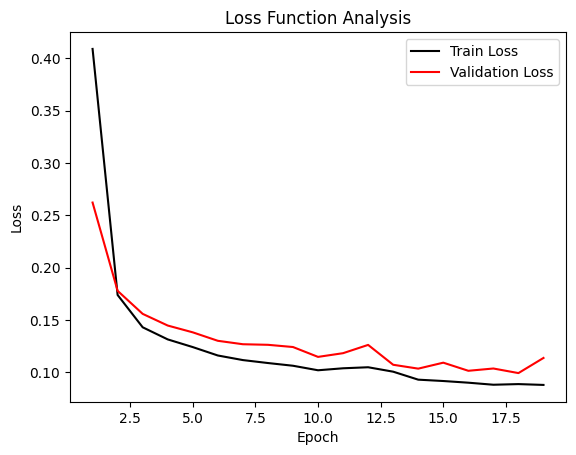

In [12]:
loss_function_analysis(history)

In [13]:
pred = model.predict([windows,sensor_ids_encoded])

273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [14]:
scaled_point_errors = np.square(windows[:, :, 0] - pred[:, :, 0])
print(f"Scaled error (diagnostic) -- mean: {scaled_point_errors.mean():.4f}, "
      f"std: {scaled_point_errors.std():.4f}, max: {scaled_point_errors.max():.4f}")

Scaled error (diagnostic) -- mean: 0.3260, std: 0.8399, max: 39.6978


In [15]:
#Timestamp in each window are saved and if multiple timestamps are available in multiple windows, their point errors are aggregated to mean.
#Inverse Data and test on original numbers
point_error_map = defaultdict(list)
timestamp_lookup = {}

window_idx = 0
for sensor in data['SID'].unique():
    sensor_data = data[data['SID'] == sensor].reset_index(drop=True)
    timestamps = sensor_data['timestamp']
    scaler = scalers[sensor]
    n_windows = len(sensor_data) - window_size + 1

    for i in range(n_windows):
        pred_scaled = pred[window_idx, :, 0].reshape(-1, 1)
        actual_scaled = windows[window_idx, :, 0].reshape(-1, 1)

        pred_unscaled = scaler.inverse_transform(pred_scaled).flatten()
        actual_unscaled = scaler.inverse_transform(actual_scaled).flatten()

        unscaled_errors = np.abs(actual_unscaled - pred_unscaled)

        for j in range(window_size):
            position = i + j
            point_error_map[(sensor, position)].append(unscaled_errors[j])
            timestamp_lookup[(sensor, position)] = timestamps.iloc[position] 

        window_idx += 1

point_results = []
for (sensor, position), errors in point_error_map.items():
    location_name = data.loc[data['SID'] == sensor, 'name'].iloc[0]
    point_results.append({
        'SID': sensor,
        'location': location_name,
        'timestamp': timestamp_lookup[(sensor, position)],
        'point_error': np.mean(errors),
    })

point_results = pd.DataFrame(point_results)
point_results.head()

,SID,location,timestamp,point_error
0,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 03:00:00+02:00,5.507971
1,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 04:00:00+02:00,3.930658
2,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 05:00:00+02:00,5.467766
3,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 06:00:00+02:00,4.941959
4,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 07:00:00+02:00,8.390902


In [16]:
point_results.sort_values('point_error', ascending=False).head(20)[
    ['SID', 'timestamp', 'point_error', 'location']
]

,SID,timestamp,point_error,location
462,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-05 10:00:00+02:00,407.285650,Innenstadt
630,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-12 10:00:00+02:00,388.110879,Innenstadt
464,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-05 12:00:00+02:00,262.698906,Innenstadt
539,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-08 15:00:00+02:00,223.485359,Innenstadt
446,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-04 18:00:00+02:00,215.677254,Innenstadt
612,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-11 16:00:00+02:00,209.969119,Innenstadt
614,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-11 18:00:00+02:00,209.568345,Innenstadt
444,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-04 16:00:00+02:00,206.754533,Innenstadt
606,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-11 10:00:00+02:00,204.162860,Innenstadt
8527,ee395b0b-5be7-4e62-b331-4207ba179629,2025-07-06 11:00:00+02:00,201.488483,Parkstraße 4


In [17]:
def plot_error_distribution(sensor_id):
    sensor_errors = point_results.loc[point_results['SID'] == sensor_id, 'point_error']
    location = point_results.loc[point_results['SID'] == sensor_id, 'location'].iloc[0]
    sns.histplot(sensor_errors, bins=50)
    plt.title(f"Error distribution at {location}")
    plt.show()

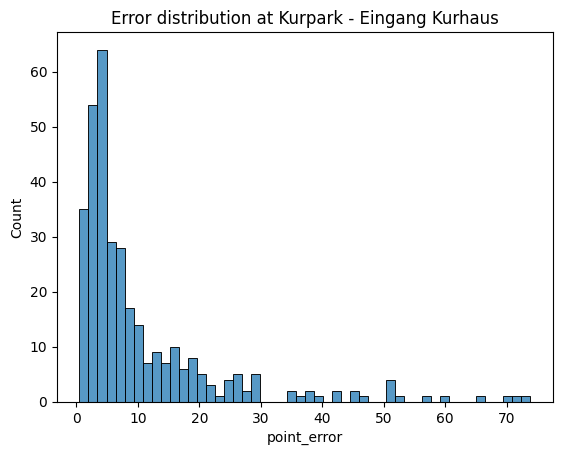

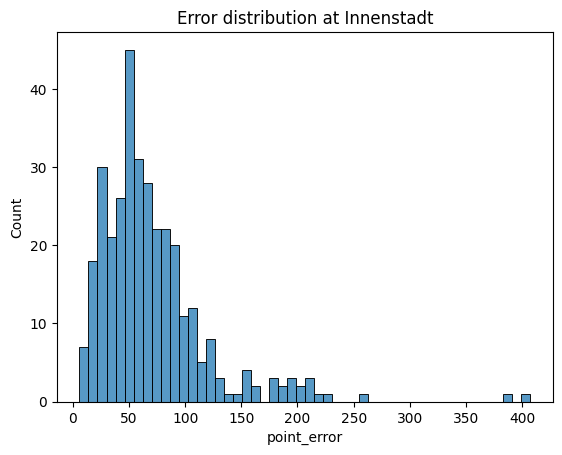

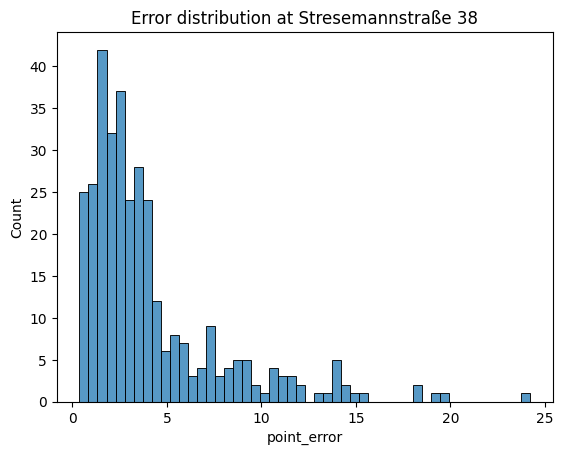

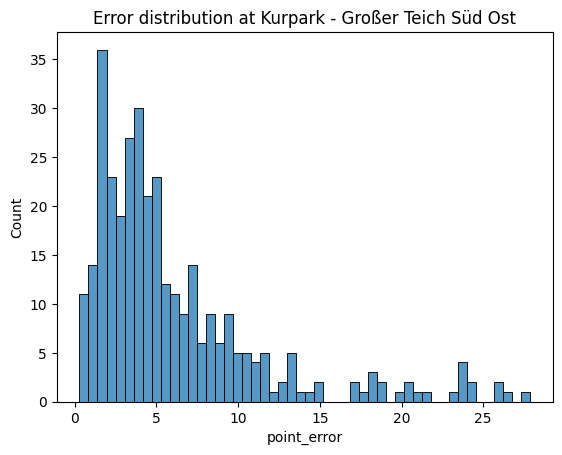

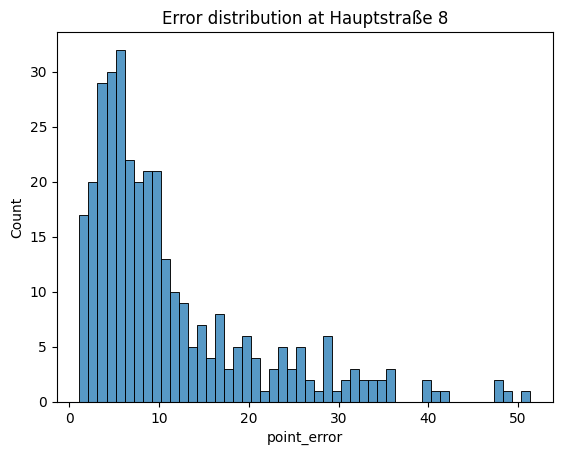

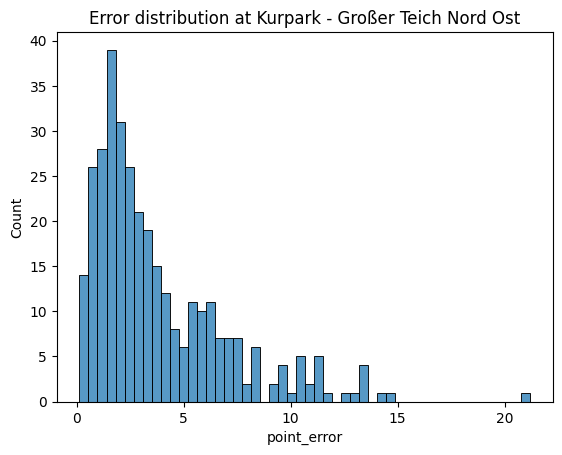

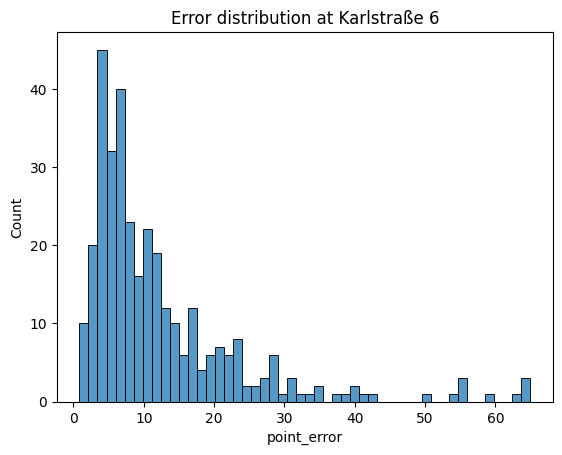

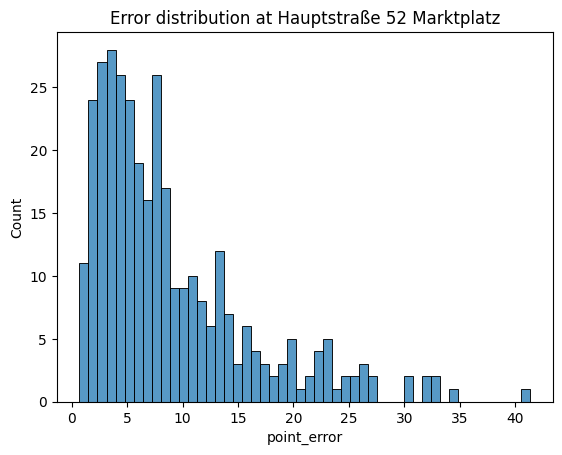

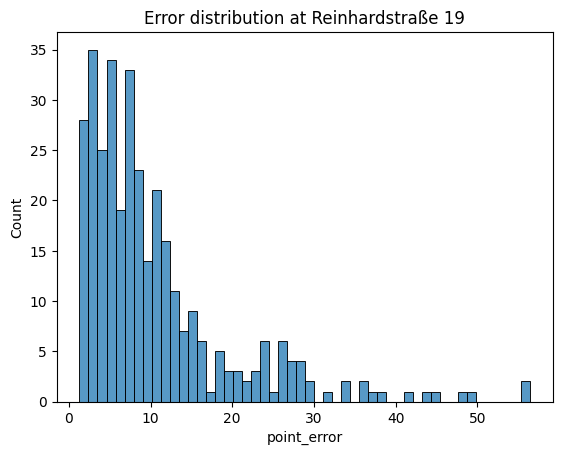

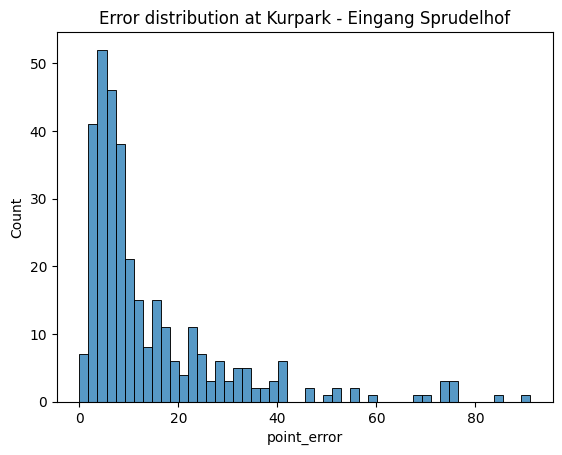

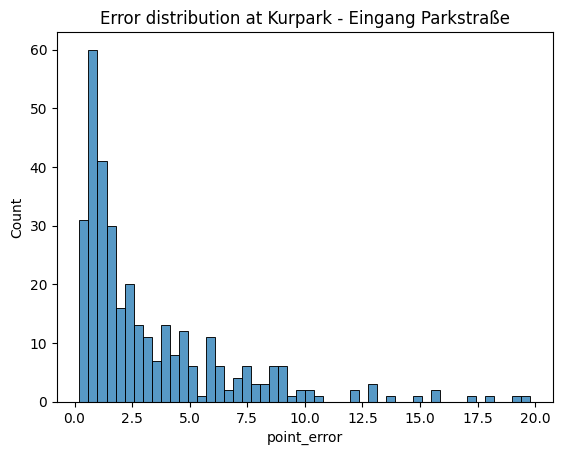

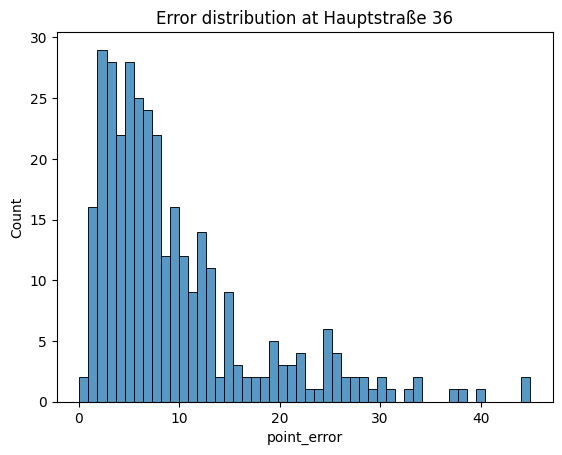

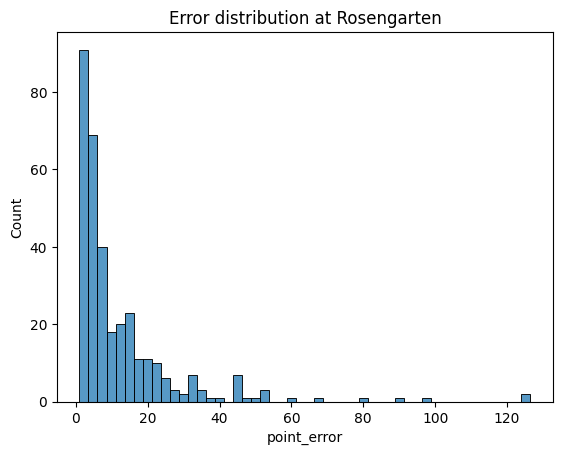

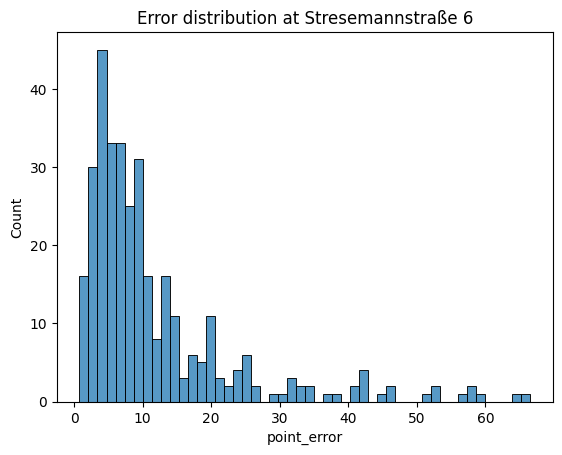

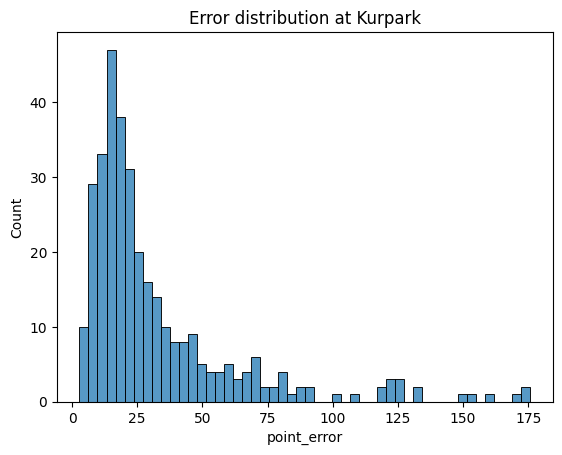

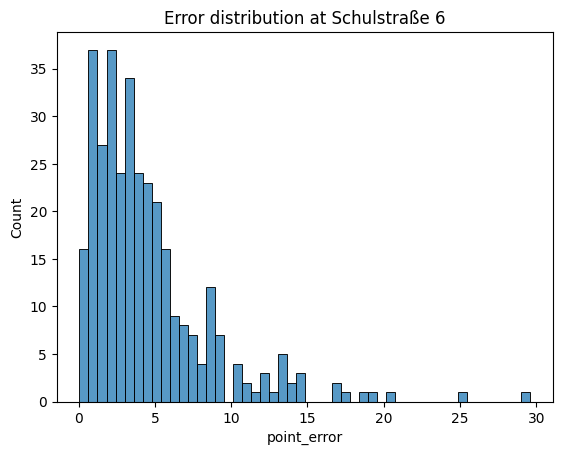

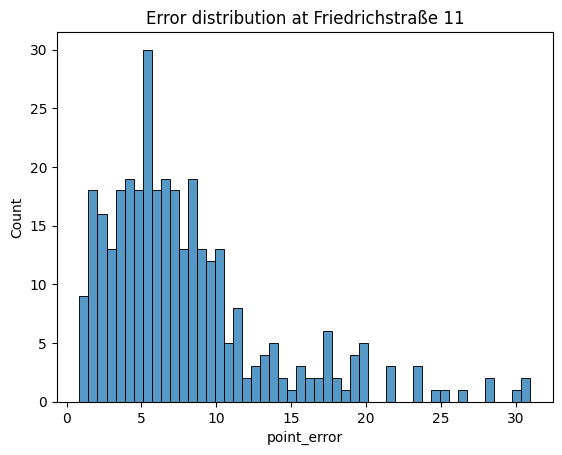

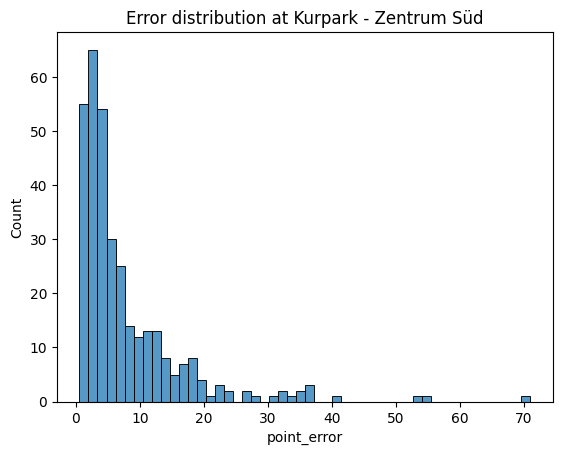

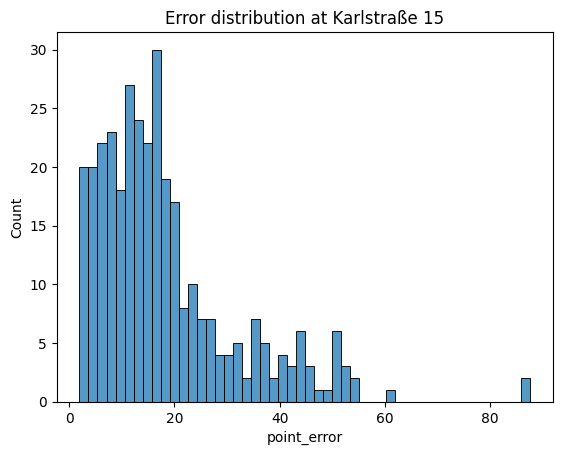

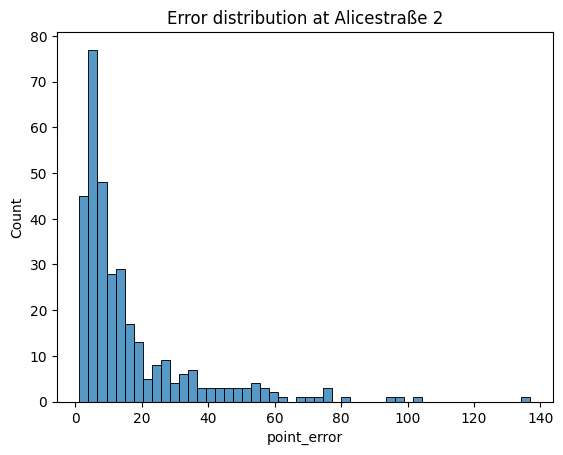

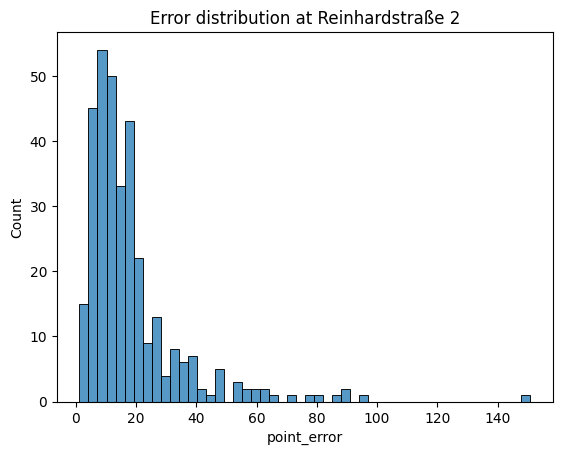

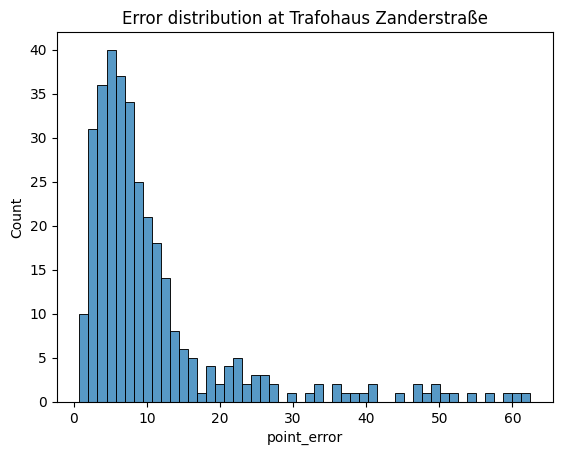

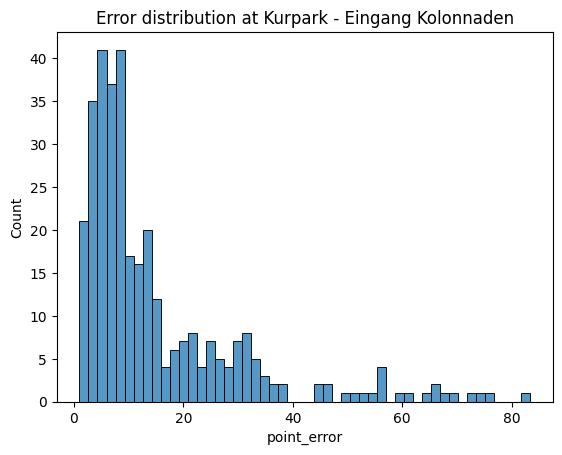

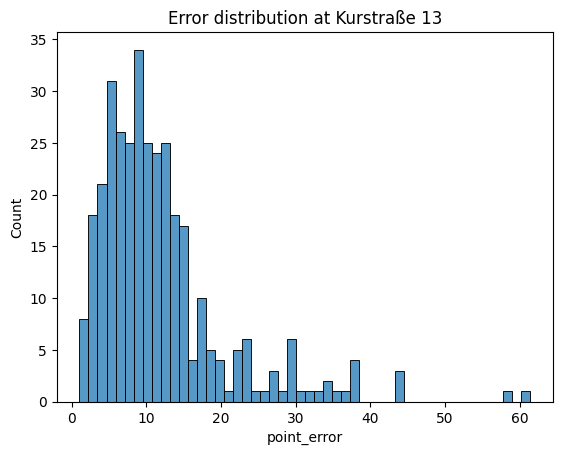

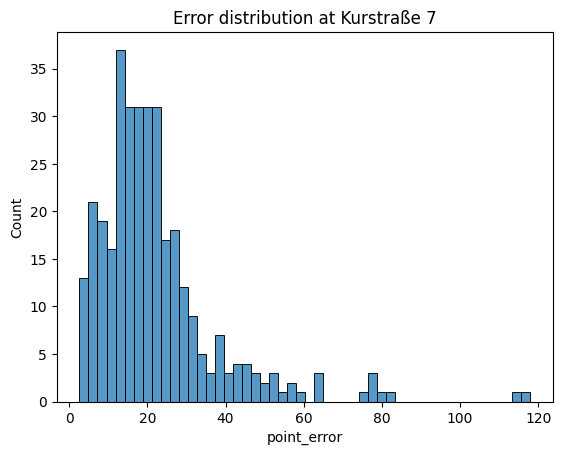

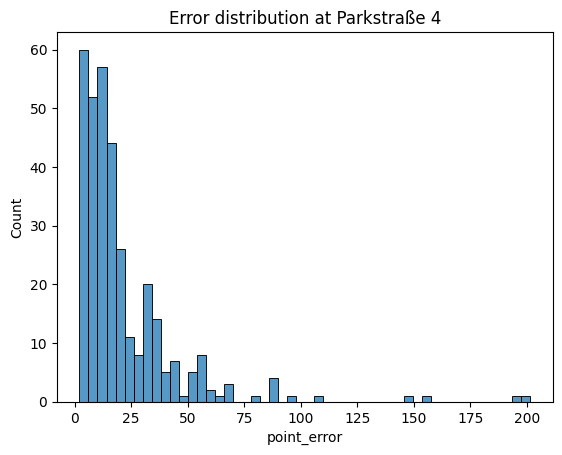

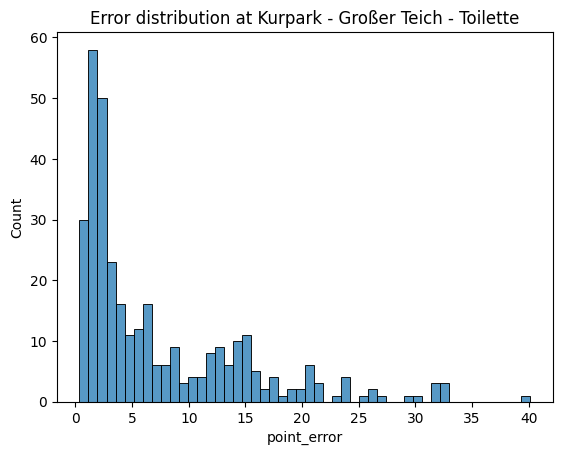

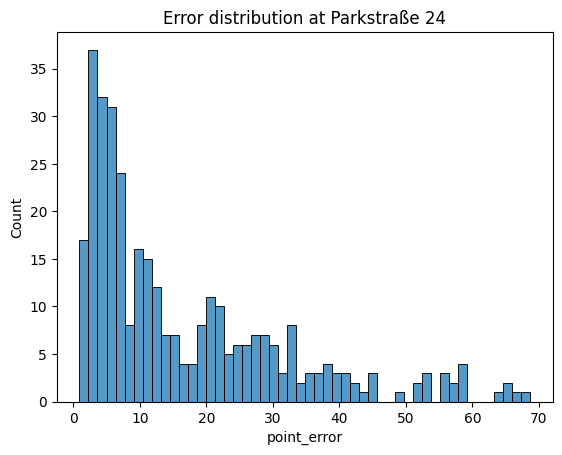

In [18]:
sensors = list(point_results['SID'].unique())

for sensor in sensors:
    plot_error_distribution(sensor)

In [19]:
point_thresholds = {}
for sensor in point_results['SID'].unique():
    errors = point_results.loc[point_results['SID'] == sensor, 'point_error']
    Q1 = np.percentile(errors, 25)
    Q3 = np.percentile(errors, 75)
    IQR = Q3 - Q1
    point_thresholds[sensor] = Q3 + 1.5 * IQR

In [20]:
point_results.to_csv('point_results.csv', index=False)

In [21]:
def plot_anomalies(sensor_id):
    sensor_data = point_results[point_results['SID'] == sensor_id].copy()
    sensor_data['timestamp'] = pd.to_datetime(sensor_data['timestamp'])
    sensor_data = sensor_data.sort_values('timestamp')
    location = sensor_data['location'].iloc[0]
    threshold = point_thresholds[sensor_id]

    anomalies = sensor_data[sensor_data['point_error'] > threshold]

    plt.figure(figsize=(12, 7))
    plt.plot(sensor_data['timestamp'], sensor_data['point_error'], label='error', color='black', linewidth=1)
    plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold:.2f}')
    plt.scatter(anomalies['timestamp'], anomalies['point_error'], color='red', s=10, marker='o',
                edgecolor='red', facecolor='white', label=f'anomaly -> count {len(anomalies)}')
    plt.xlabel('Date')
    plt.ylabel('Reconstruction Error')
    plt.title(f'Anomalies at {location}')
    plt.xticks(rotation=45)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

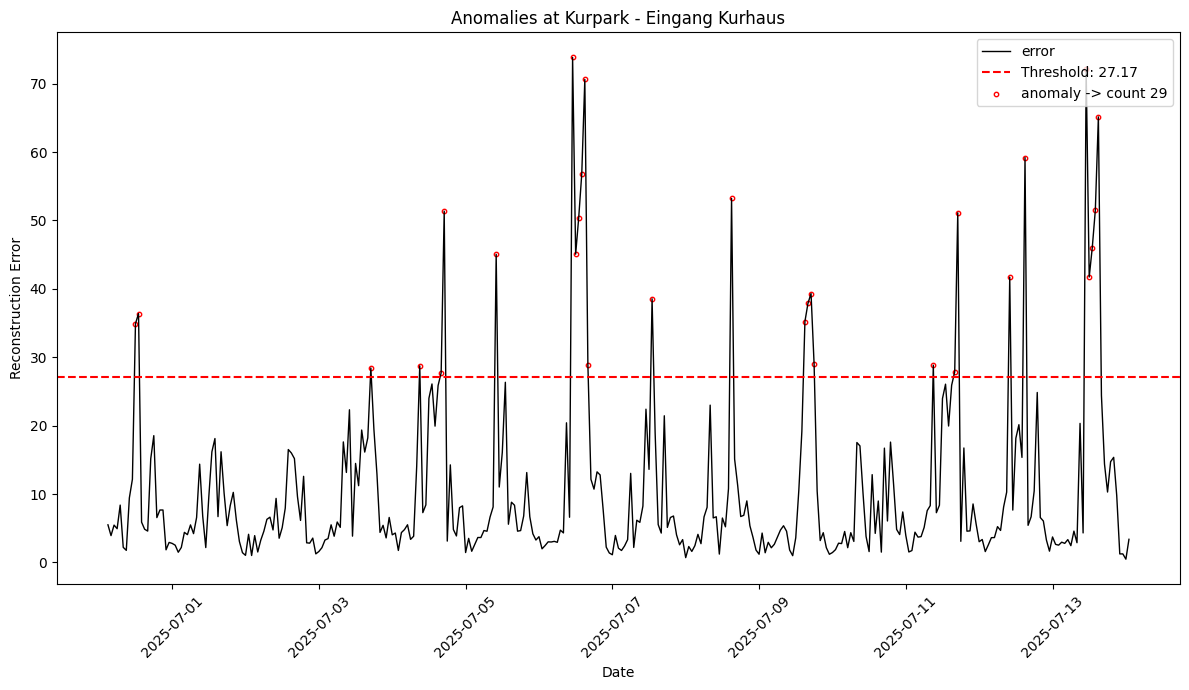

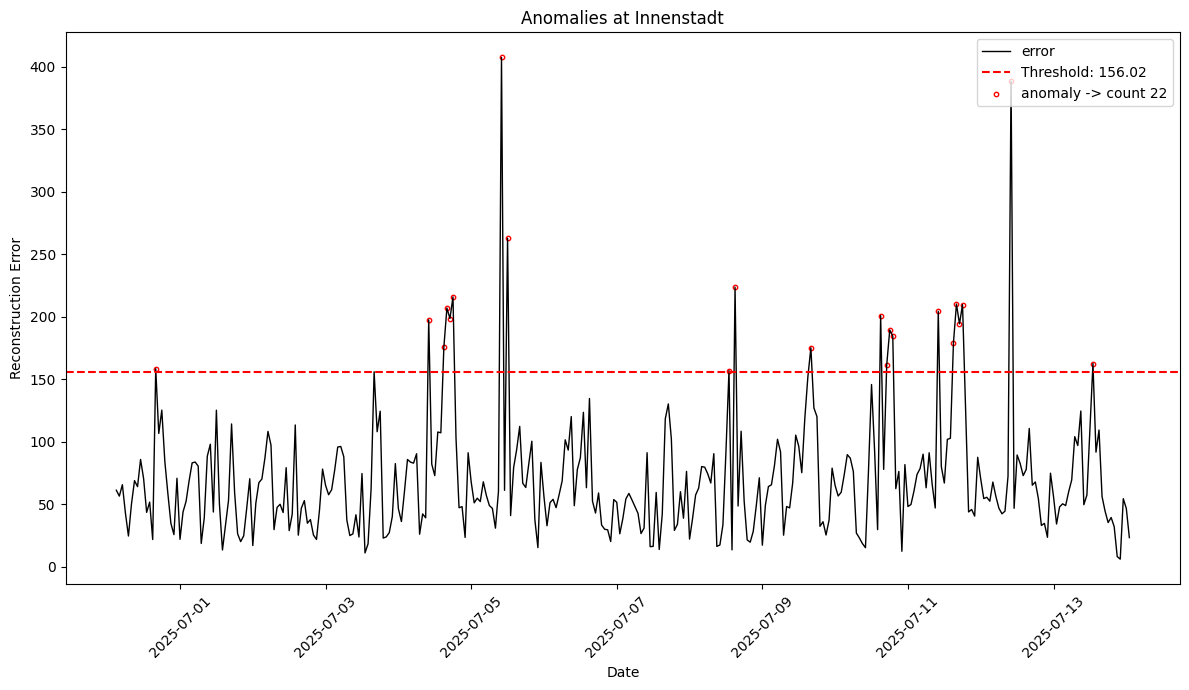

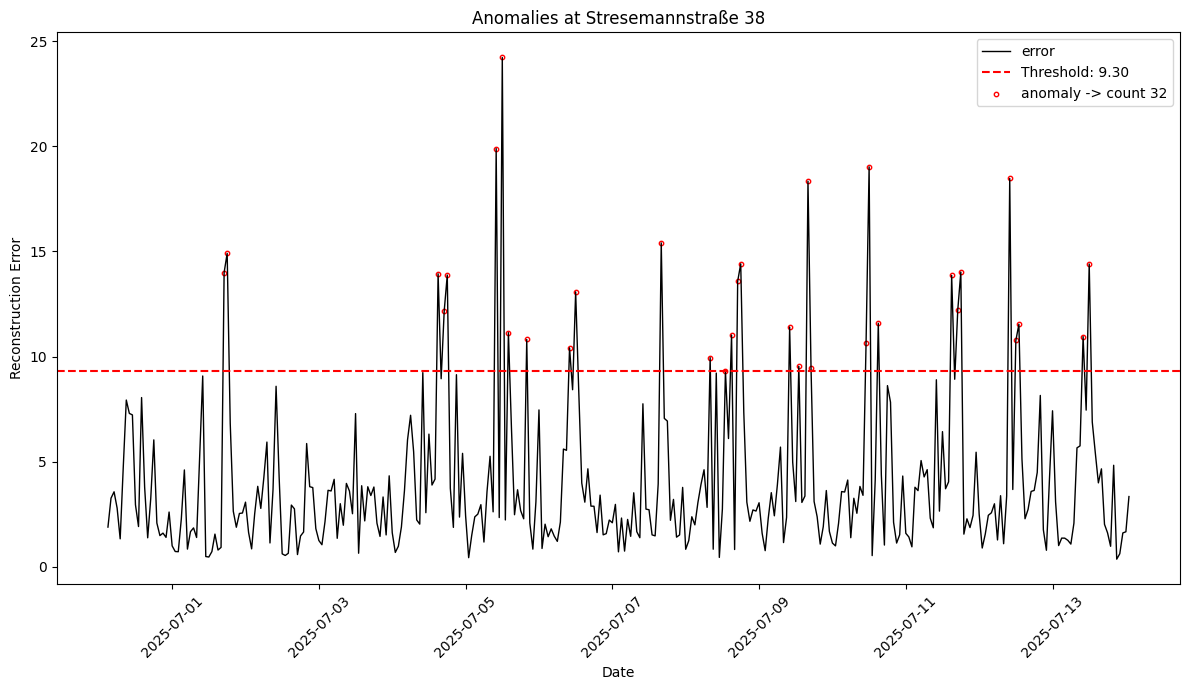

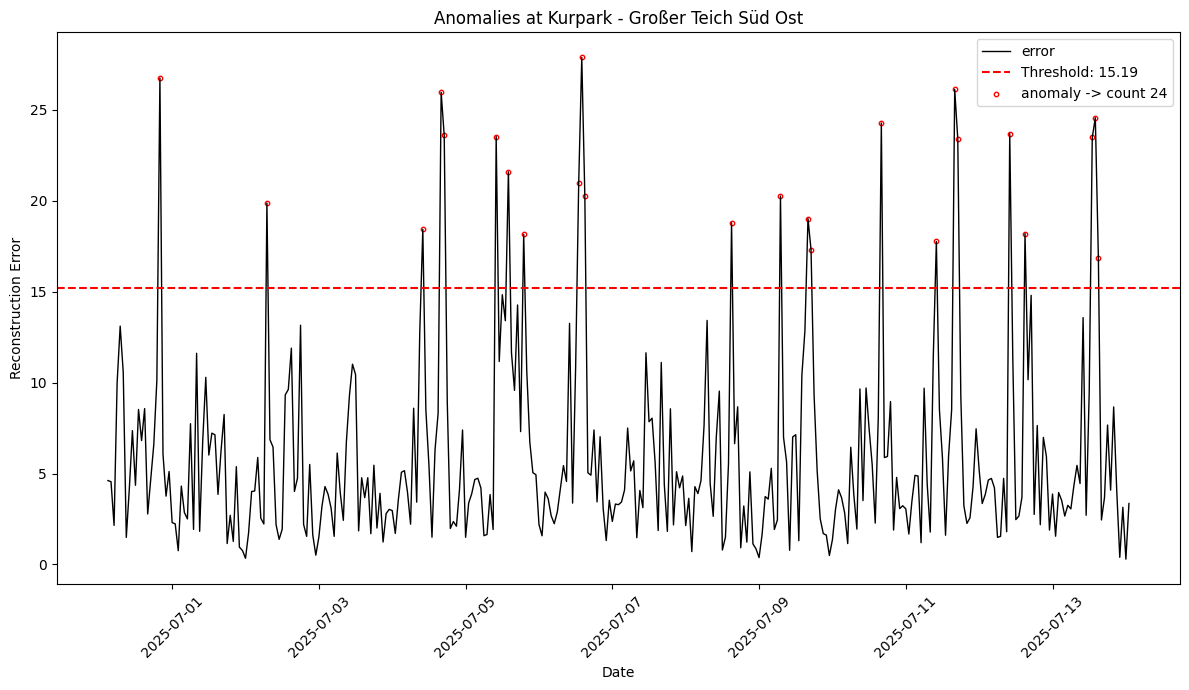

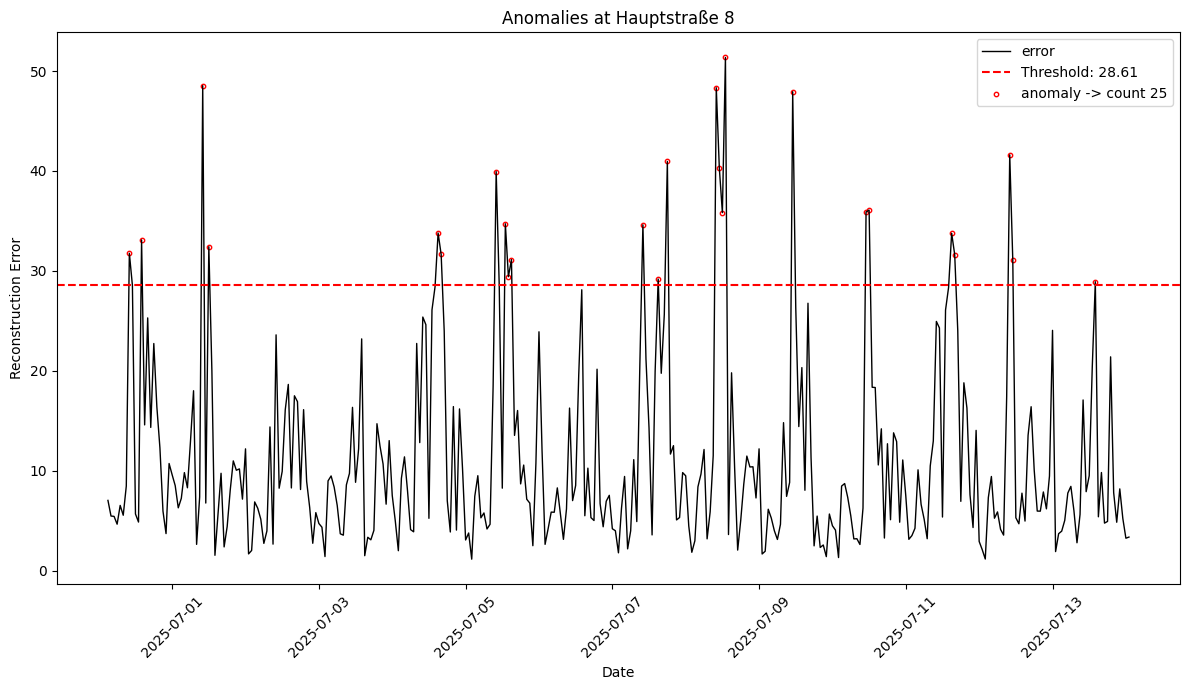

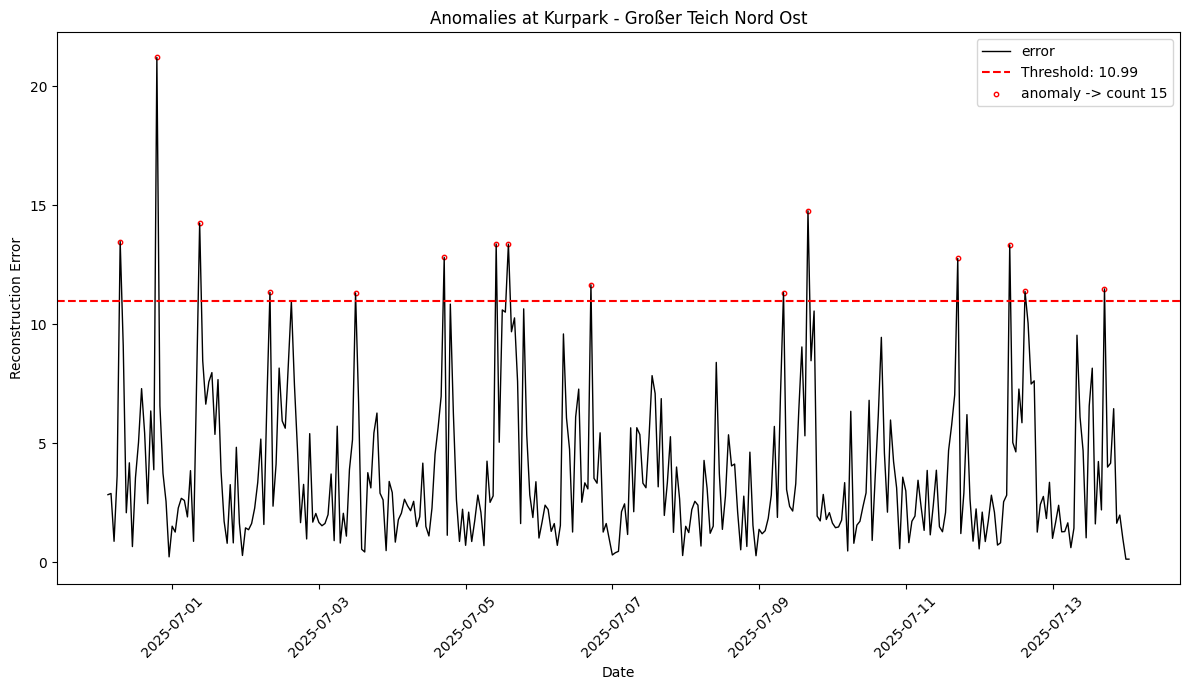

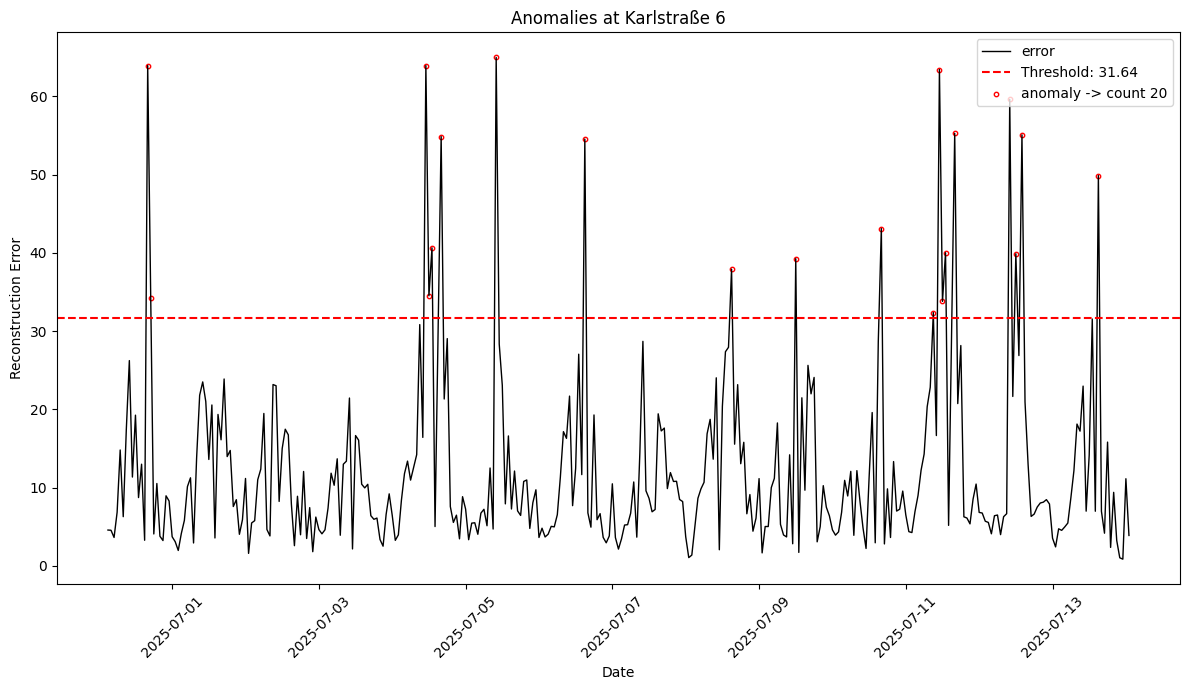

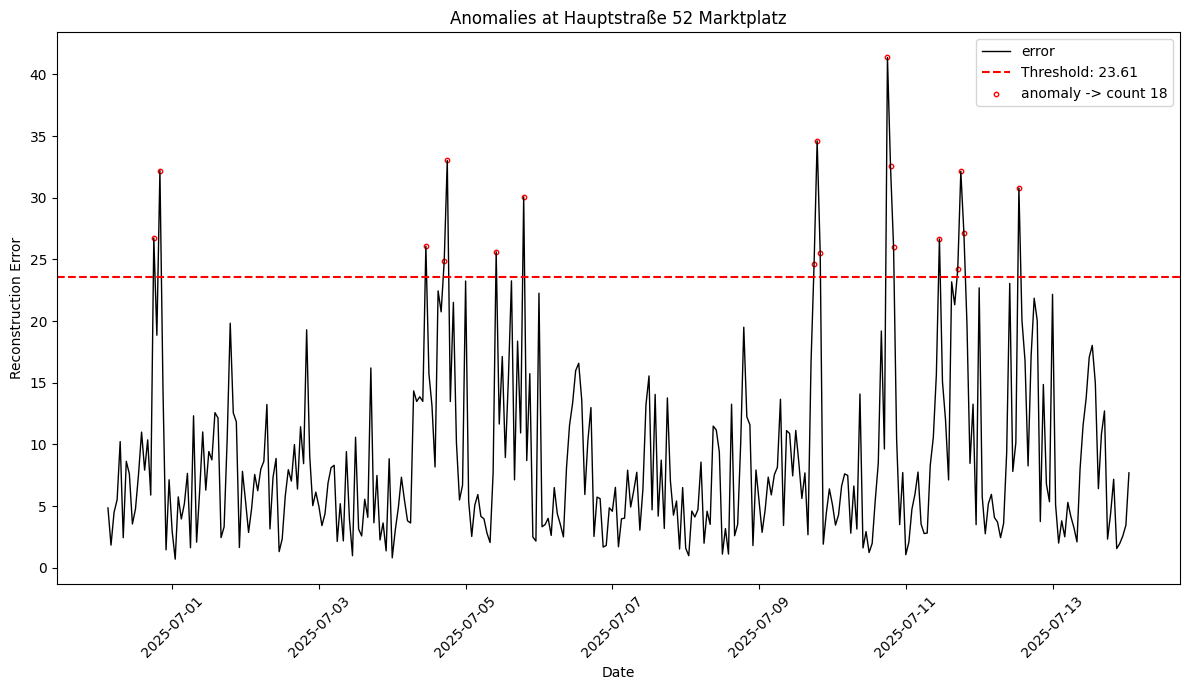

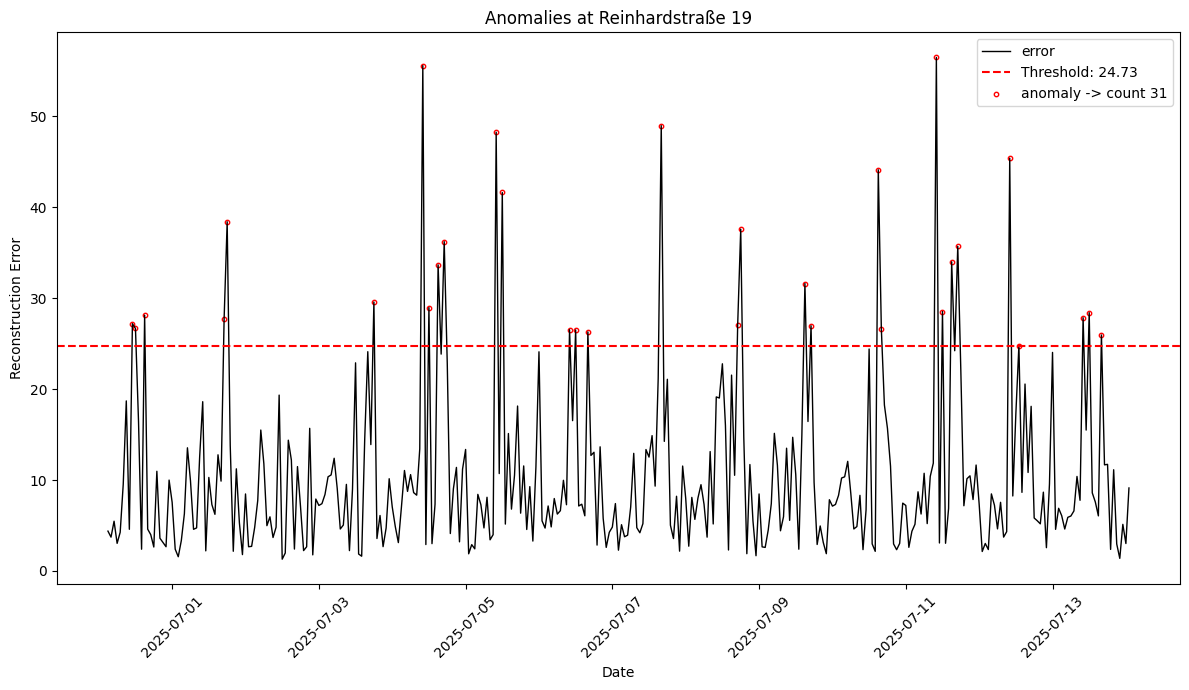

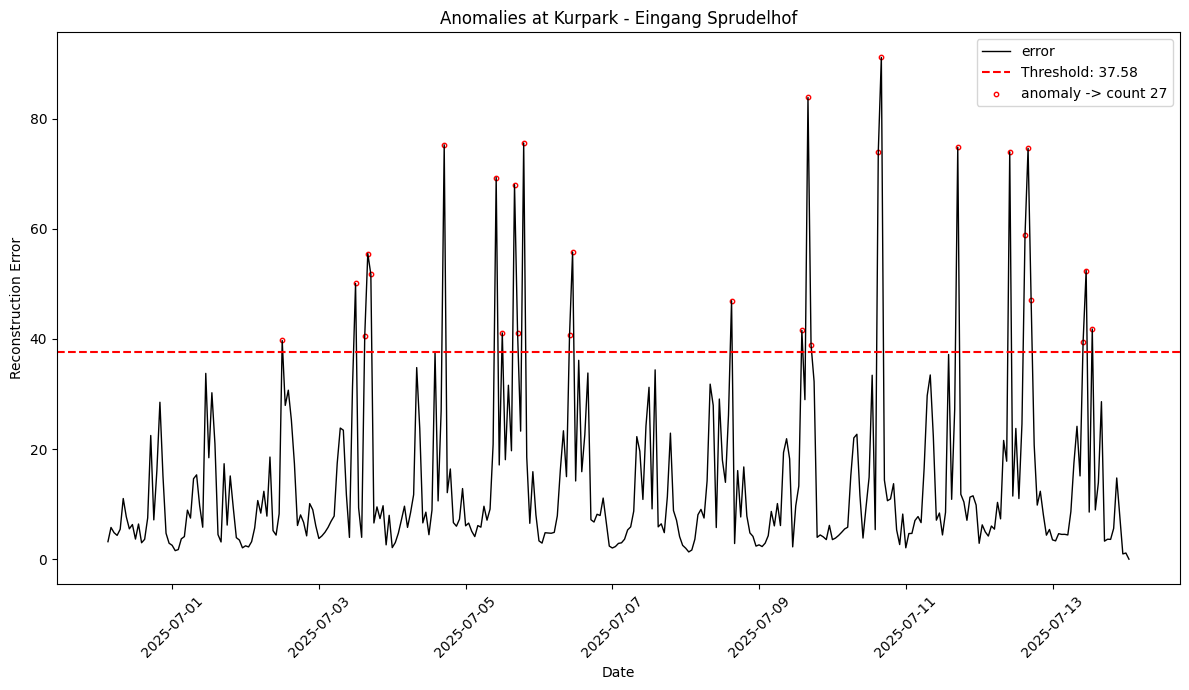

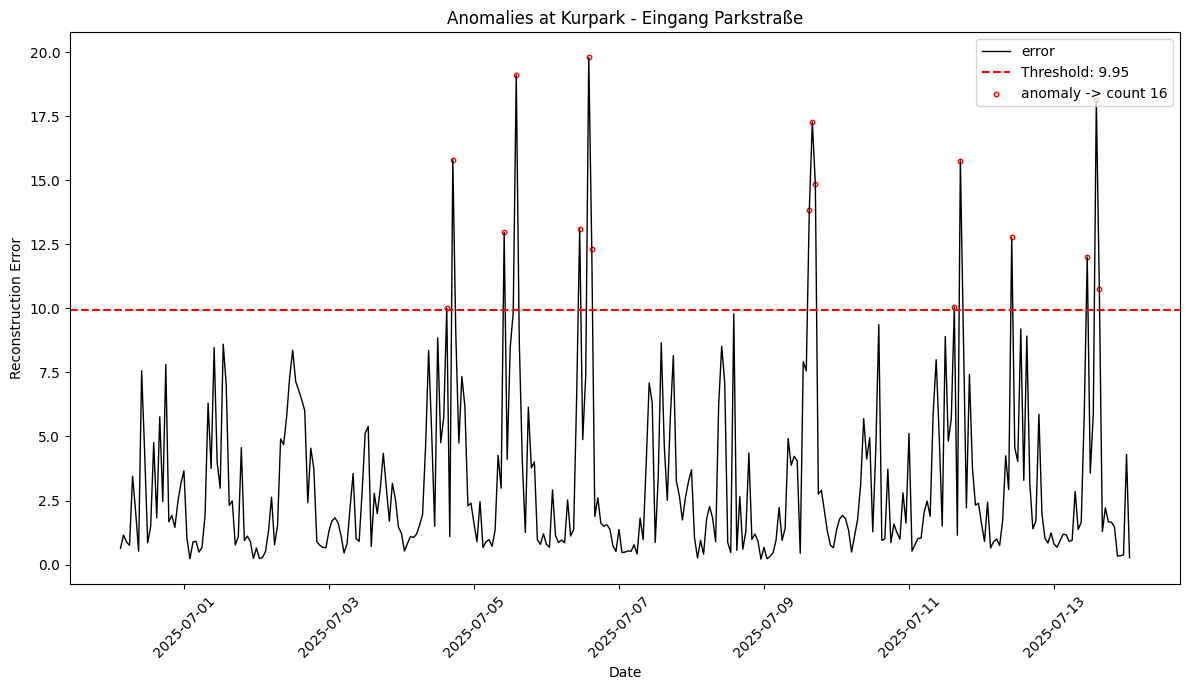

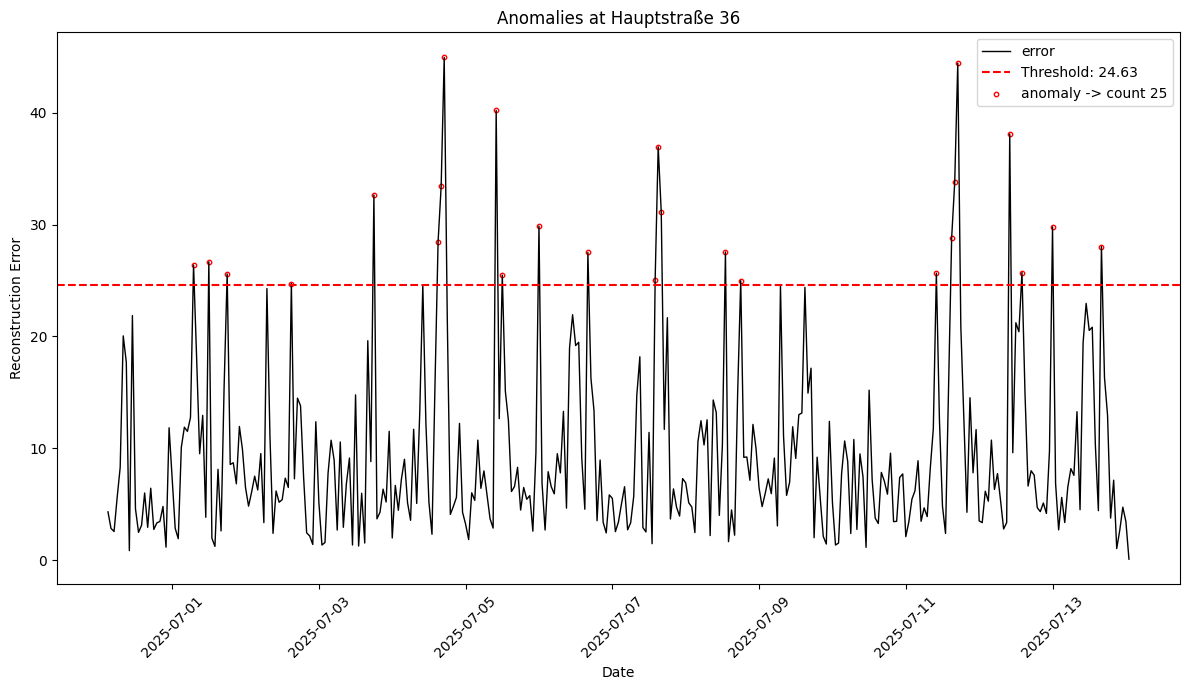

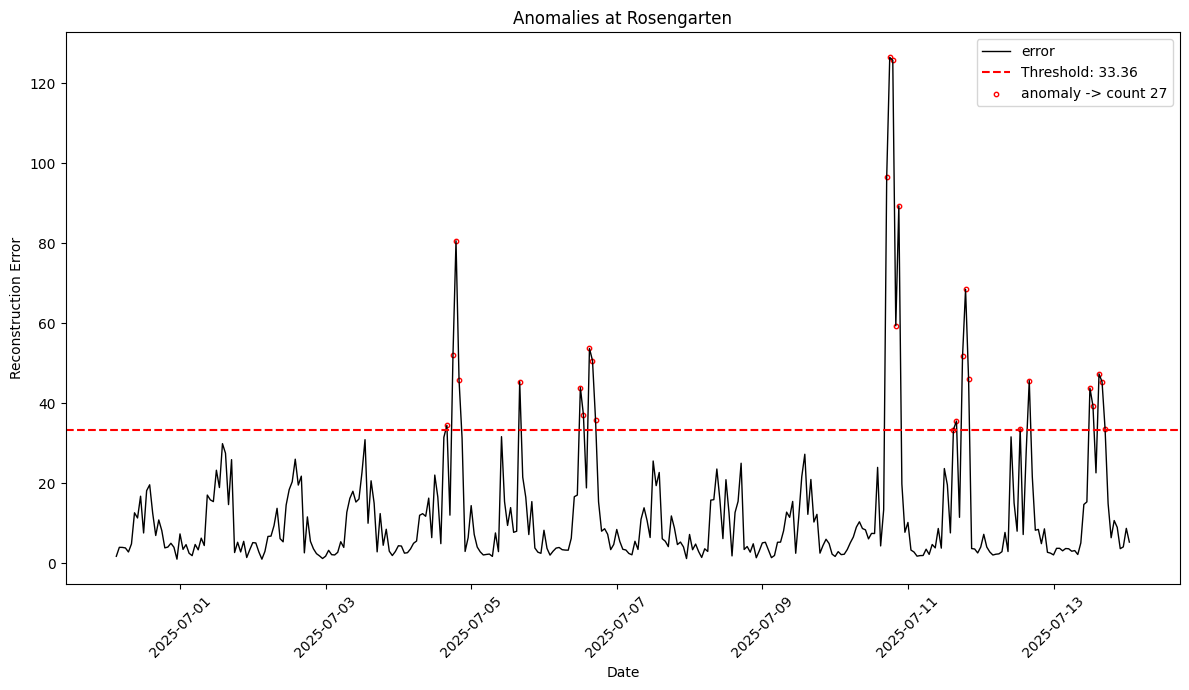

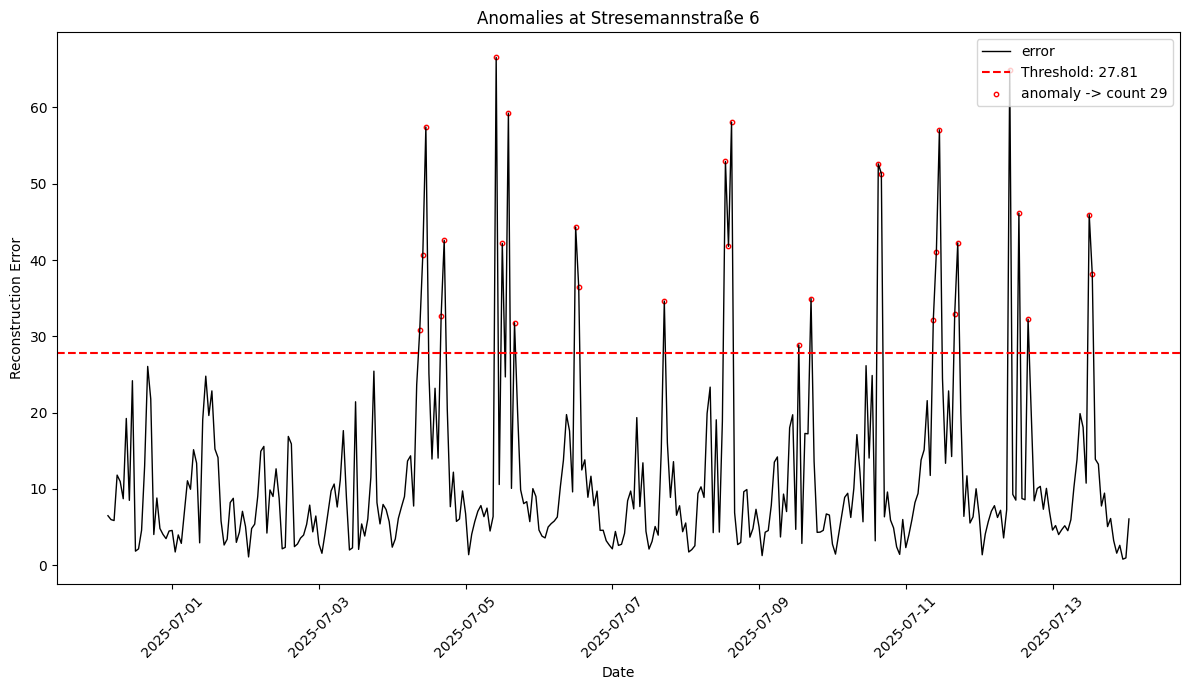

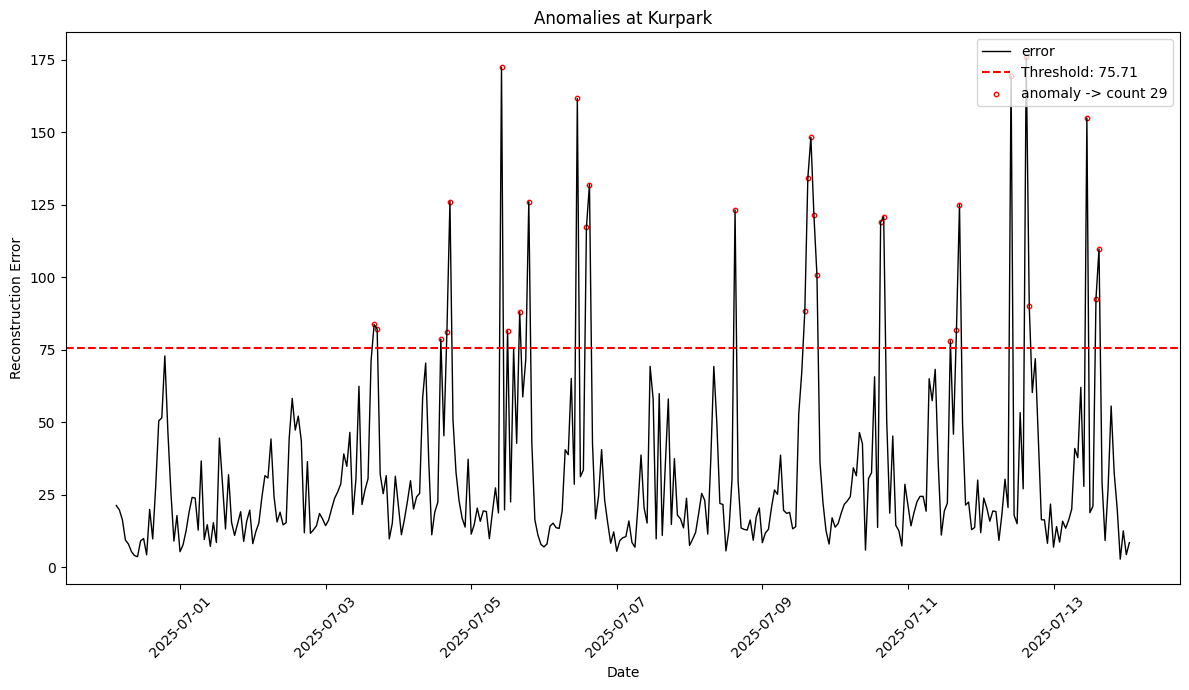

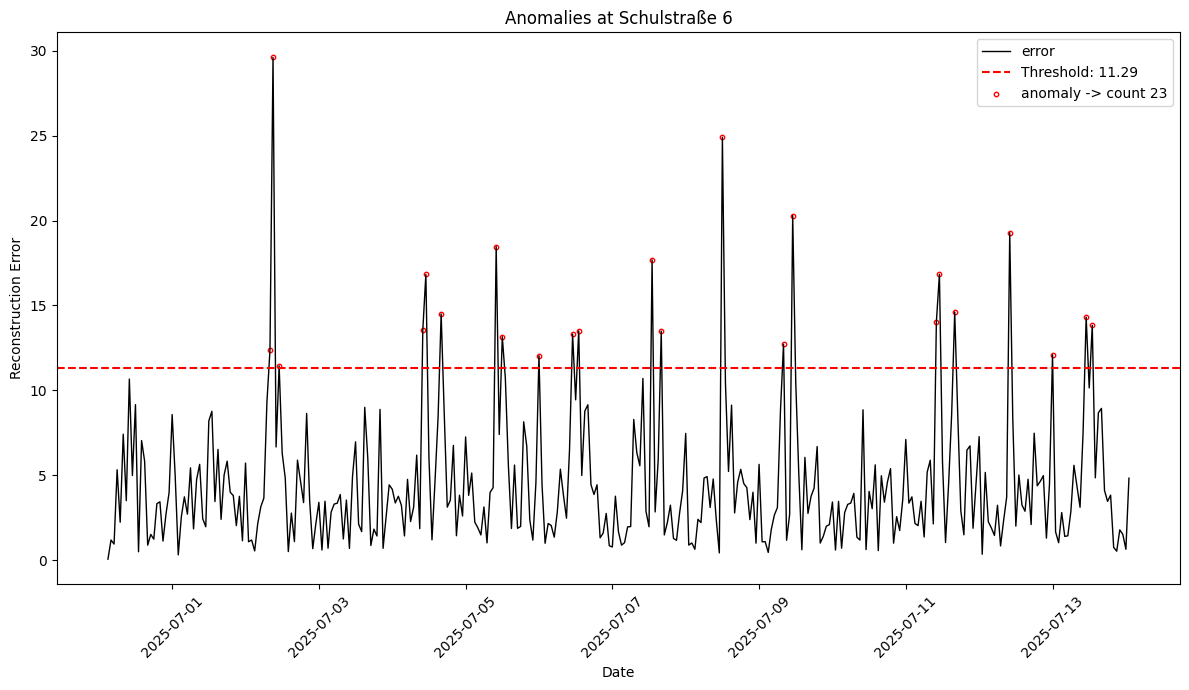

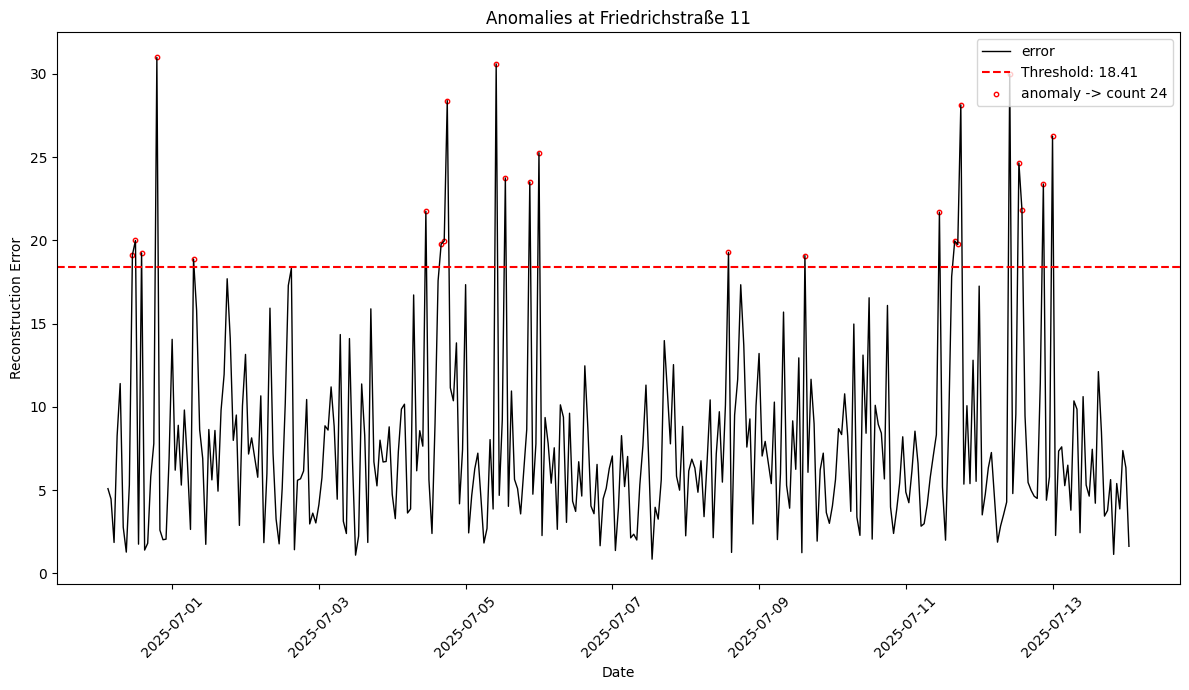

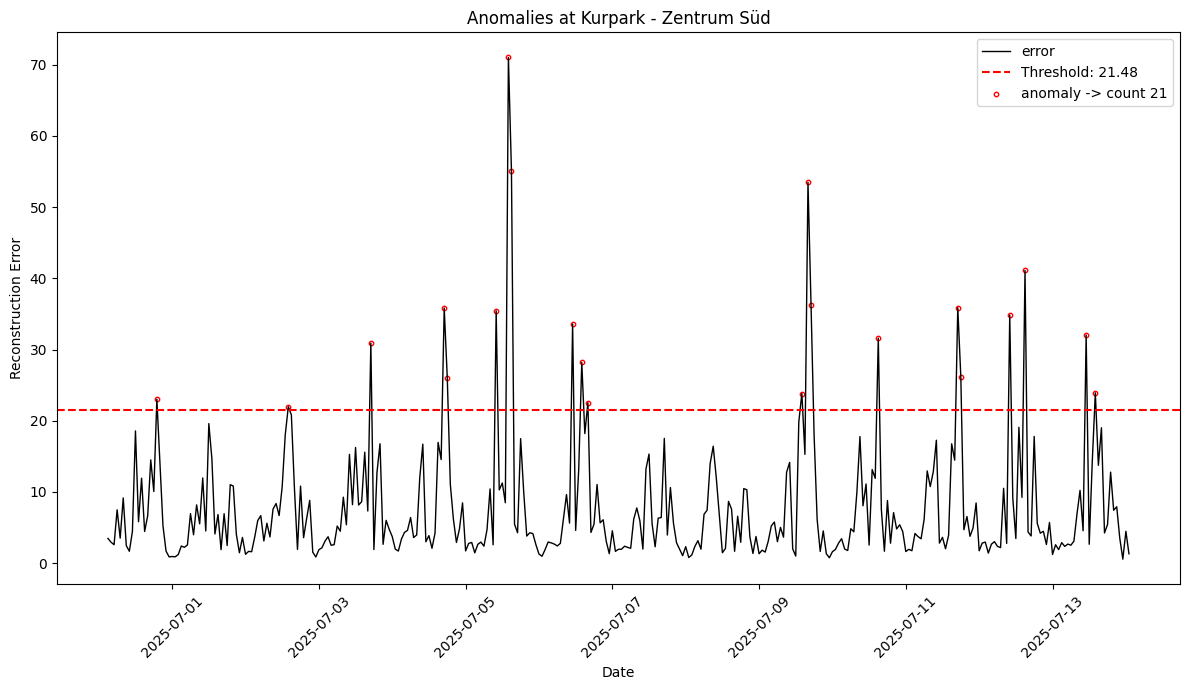

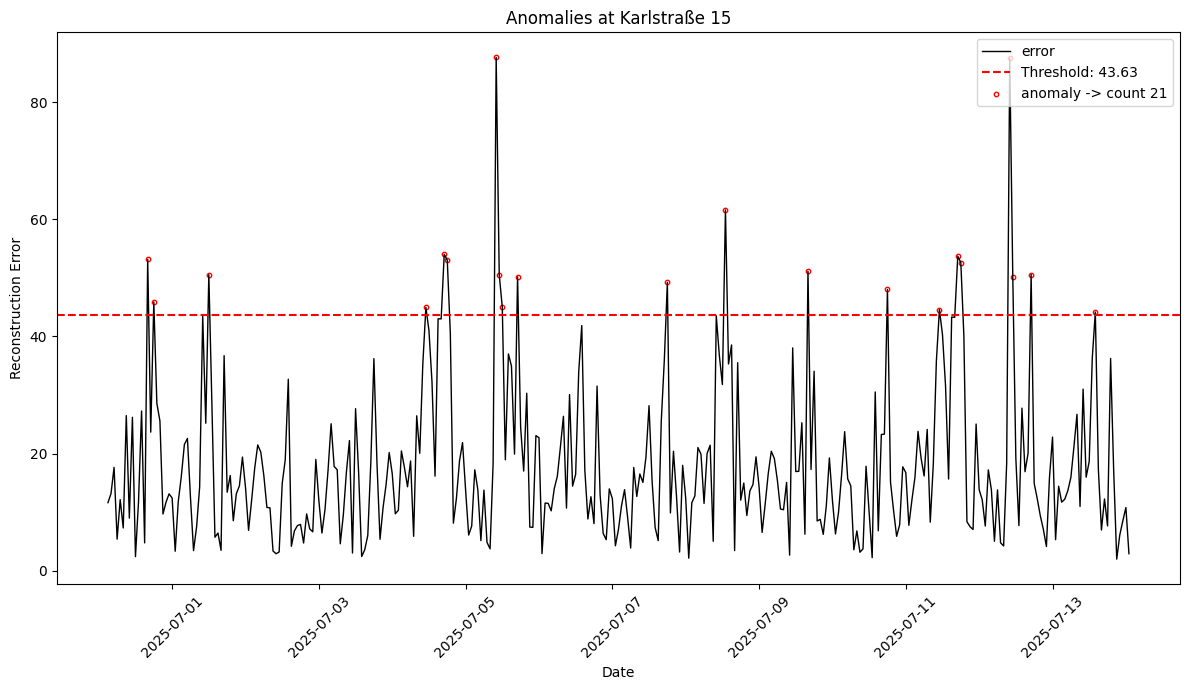

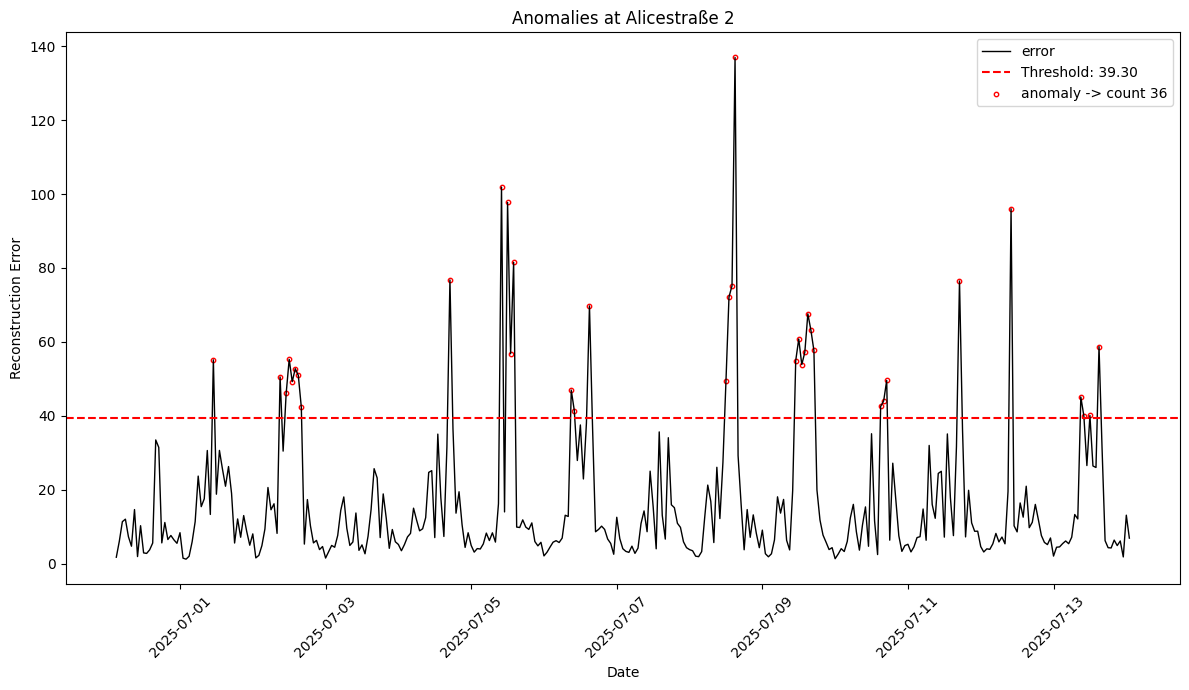

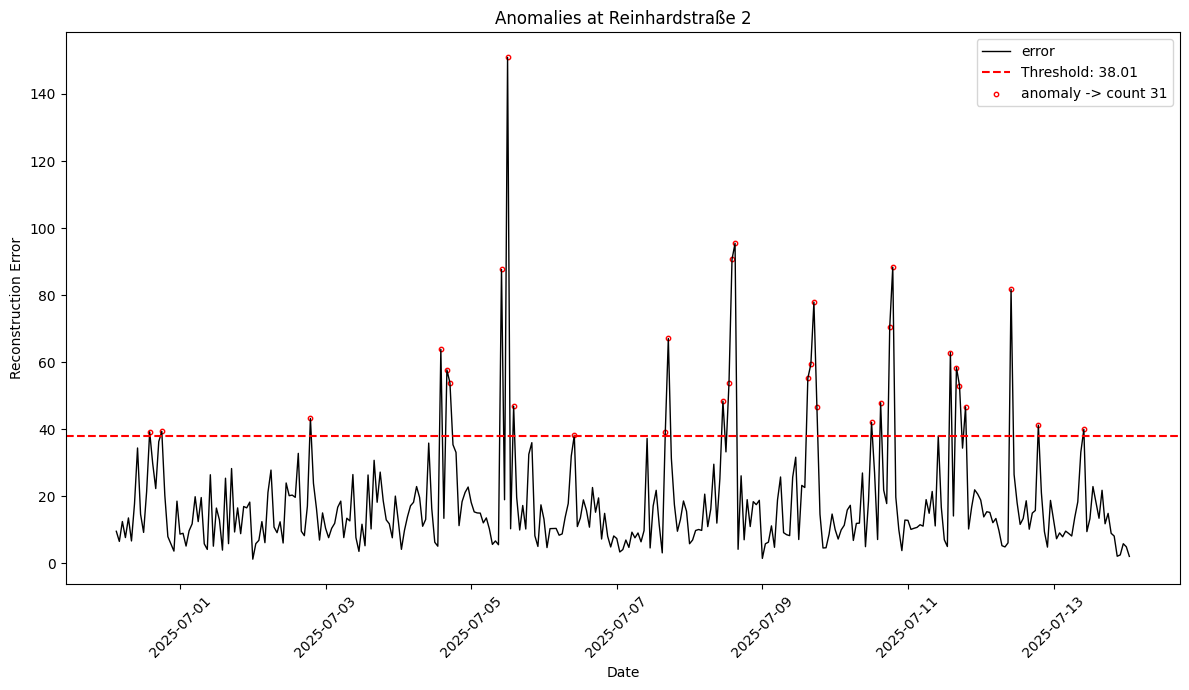

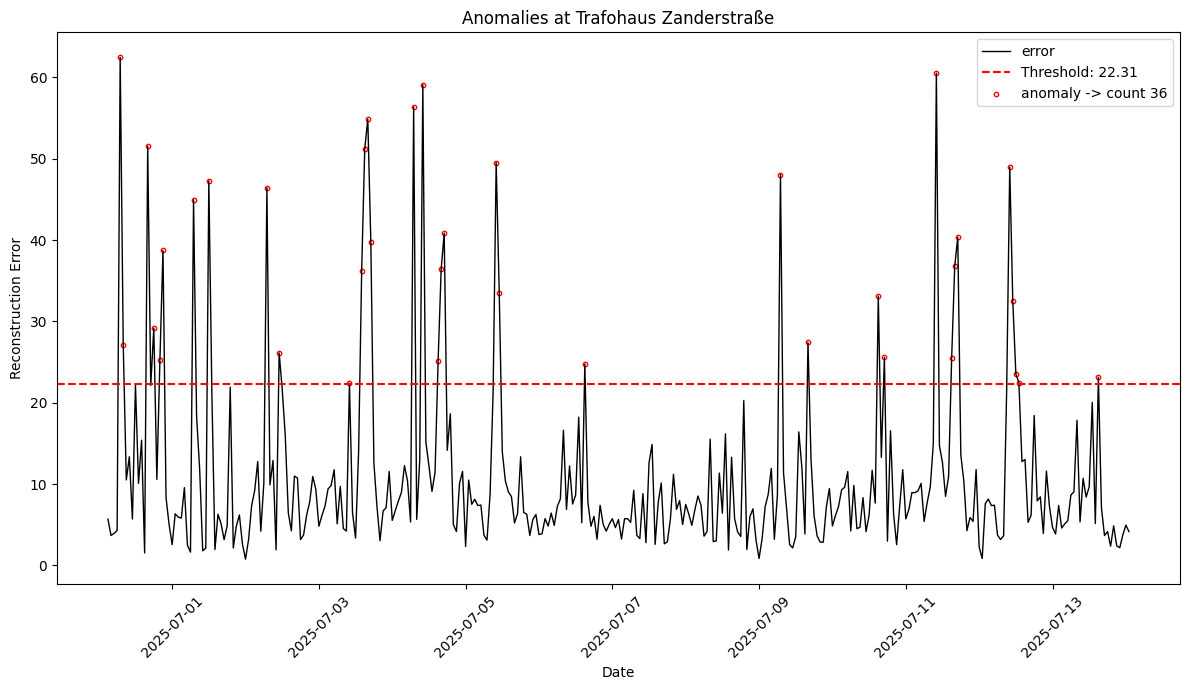

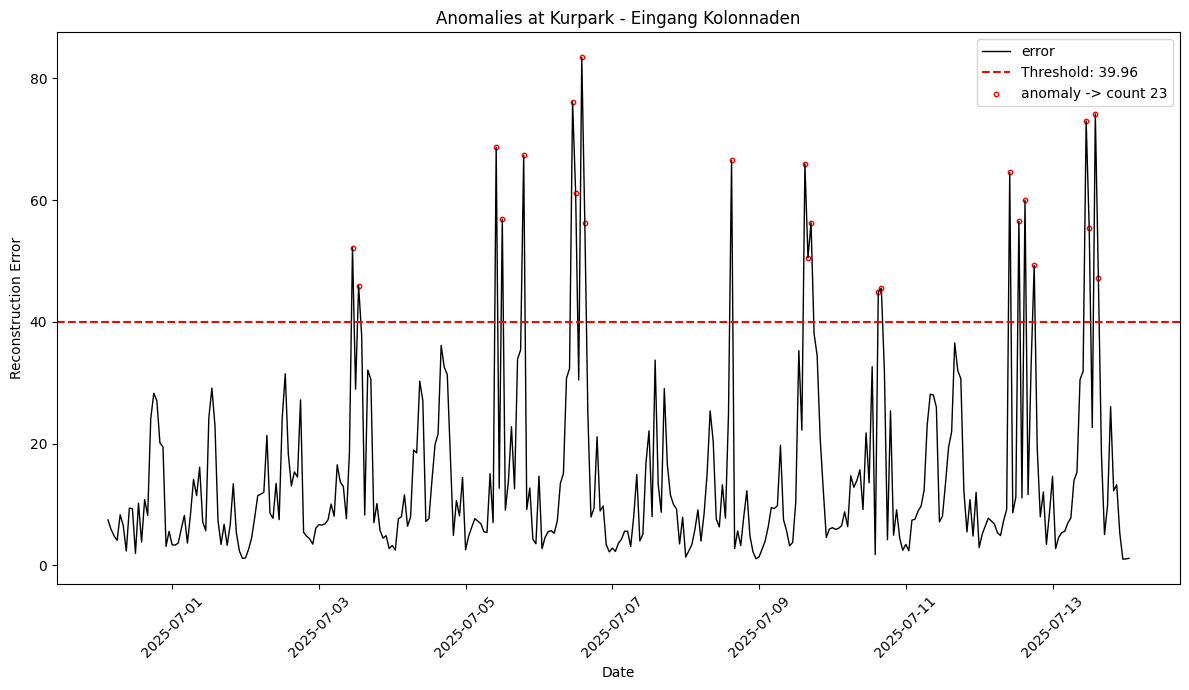

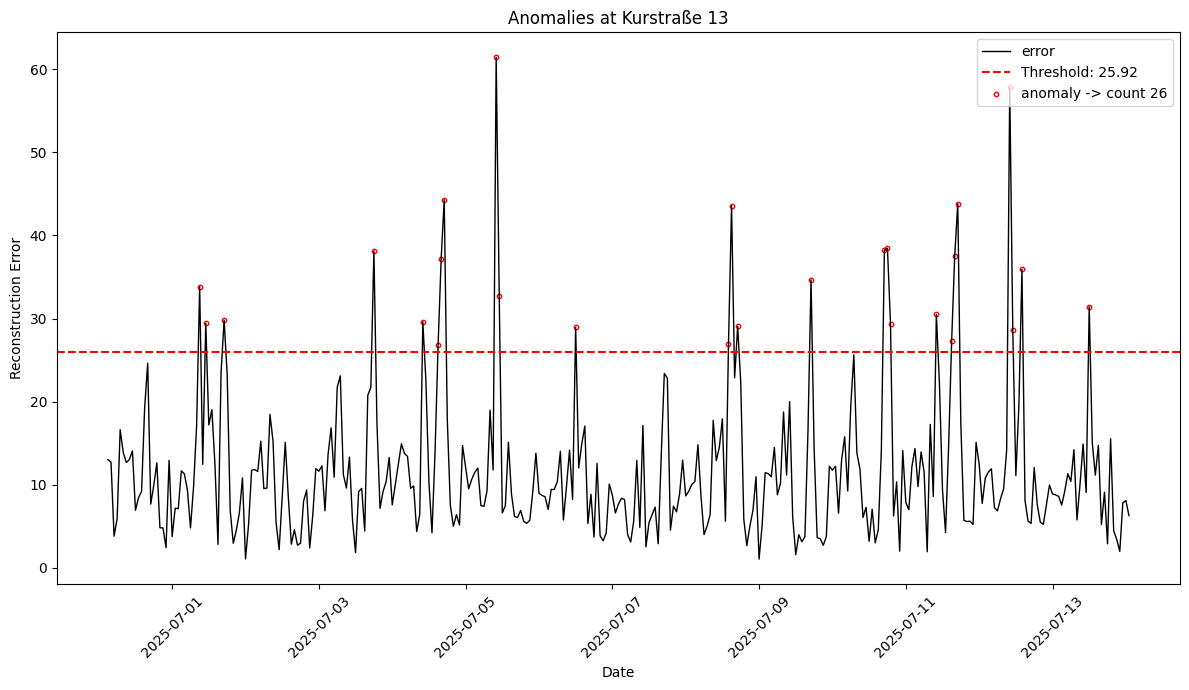

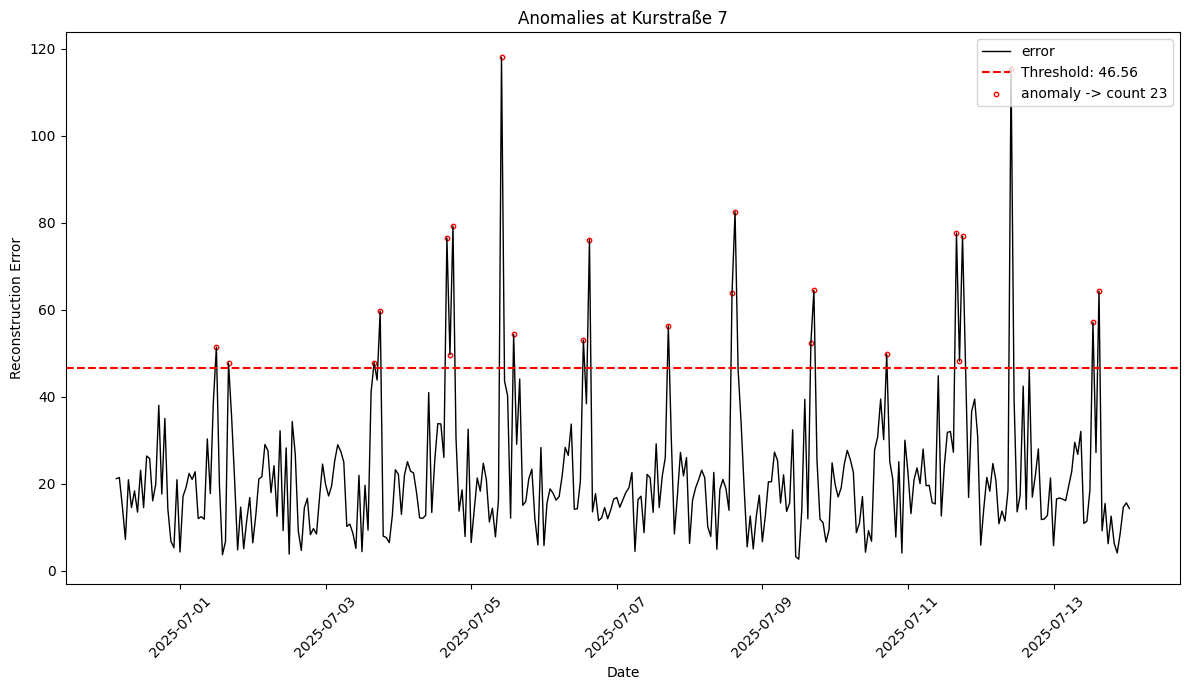

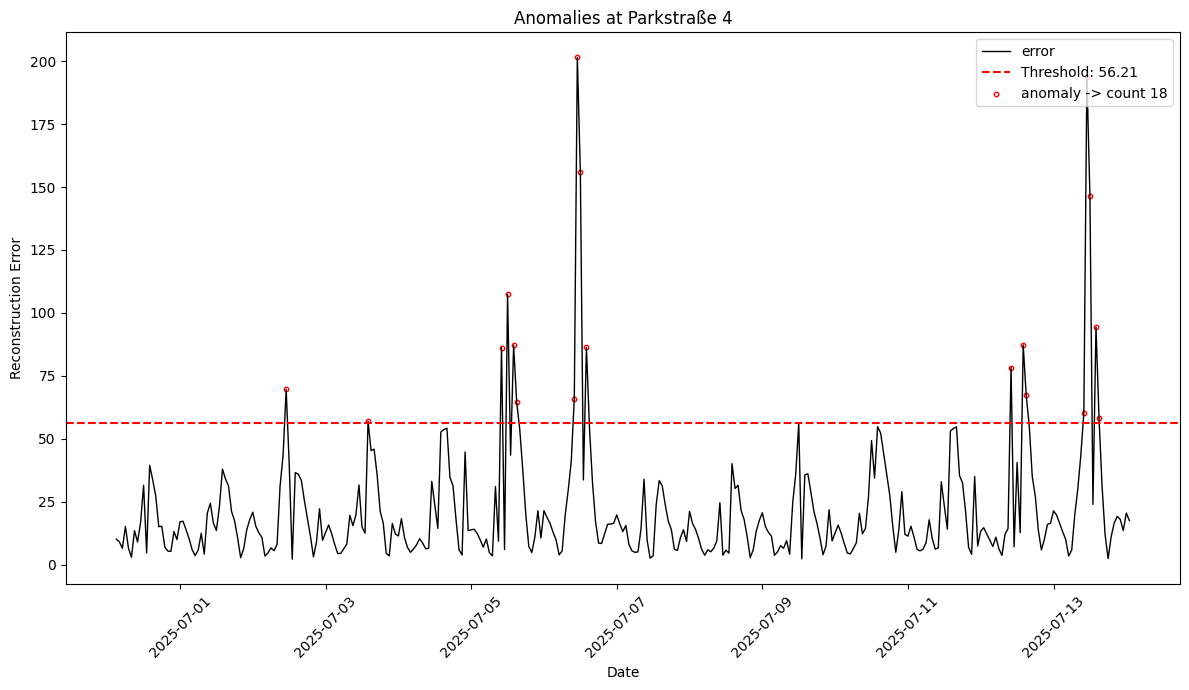

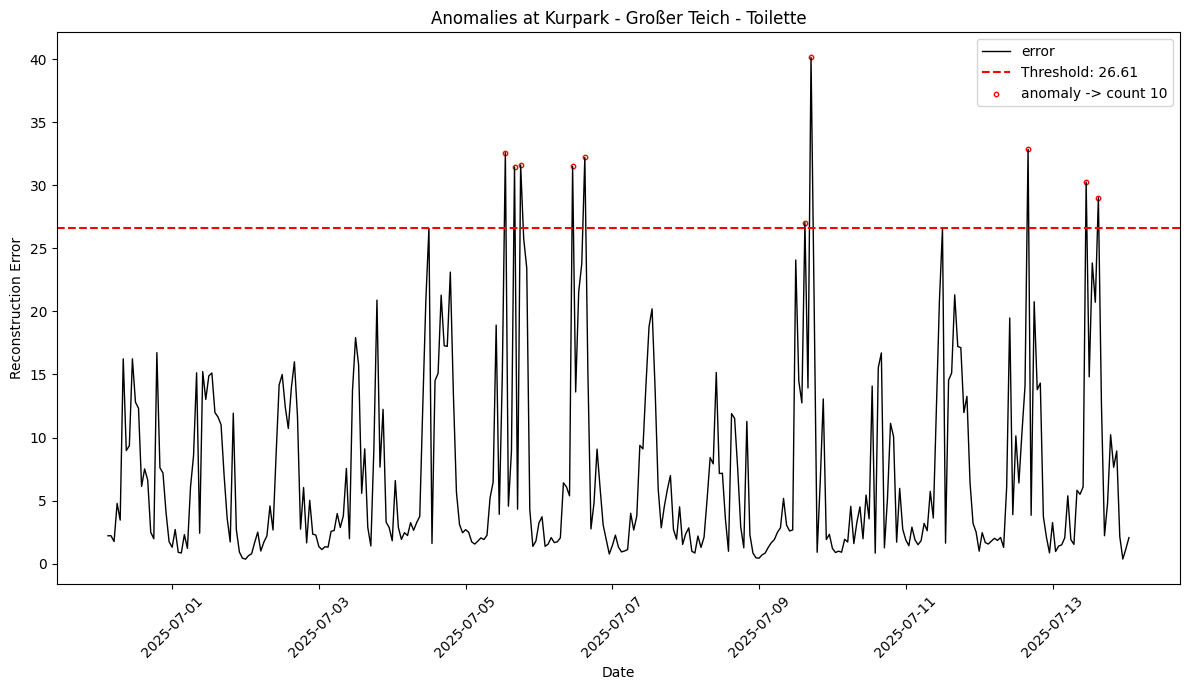

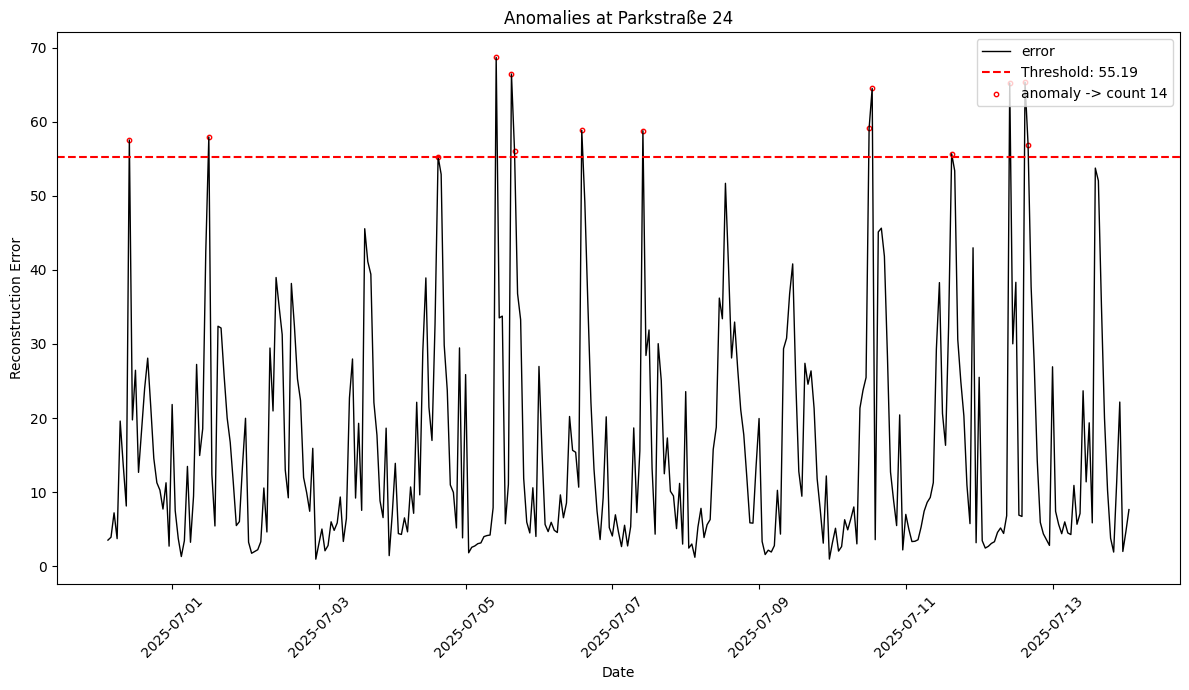

In [22]:
for sensor in sensors:
    plot_anomalies(sensor)

In [23]:
#Prepare anomaly report per sensor and location and save it
def prepare_anomaly_report(sensor_id):
    directory = Path('anomaly_report')
    directory.mkdir(parents=True, exist_ok=True)

    sensor_data = point_results[point_results['SID'] == sensor_id].copy()
    location = sensor_data['location'].iloc[0]
    threshold = point_thresholds[sensor_id]
    sensor_data['anomaly'] = np.where(sensor_data['point_error'] > threshold, 'Yes', 'No')

    output_file = directory / f"{location}.csv"
    sensor_data.to_csv(output_file, index=False)

In [24]:
for sensor in sensors:
    prepare_anomaly_report(sensor)

In [25]:
#Save model for further use
model.save('global_model.keras')

In [83]:
location = 'Innenstadt'  
report_path = Path('anomaly_report') / f"{location}.csv"
sensor_report = pd.read_csv(report_path)
anomalies = sensor_report[sensor_report['anomaly'] == 'Yes']

print(f"{len(anomalies)} anomalies detected at {location}")
anomalies

22 anomalies detected at Innenstadt


,SID,location,timestamp,point_error,anomaly
13,3cc1e766-97c5-4ed0-92c3-a800b5be8658,Innenstadt,2025-06-30 16:00:00+02:00,158.222676,Yes
103,3cc1e766-97c5-4ed0-92c3-a800b5be8658,Innenstadt,2025-07-04 10:00:00+02:00,197.385139,Yes
108,3cc1e766-97c5-4ed0-92c3-a800b5be8658,Innenstadt,2025-07-04 15:00:00+02:00,175.740908,Yes
109,3cc1e766-97c5-4ed0-92c3-a800b5be8658,Innenstadt,2025-07-04 16:00:00+02:00,206.754533,Yes
110,3cc1e766-97c5-4ed0-92c3-a800b5be8658,Innenstadt,2025-07-04 17:00:00+02:00,198.409561,Yes
111,3cc1e766-97c5-4ed0-92c3-a800b5be8658,Innenstadt,2025-07-04 18:00:00+02:00,215.677254,Yes
127,3cc1e766-97c5-4ed0-92c3-a800b5be8658,Innenstadt,2025-07-05 10:00:00+02:00,407.285650,Yes
129,3cc1e766-97c5-4ed0-92c3-a800b5be8658,Innenstadt,2025-07-05 12:00:00+02:00,262.698906,Yes
202,3cc1e766-97c5-4ed0-92c3-a800b5be8658,Innenstadt,2025-07-08 13:00:00+02:00,156.725043,Yes
204,3cc1e766-97c5-4ed0-92c3-a800b5be8658,Innenstadt,2025-07-08 15:00:00+02:00,223.485359,Yes


In [84]:
#Load injected Data for testing

injected_data = pd.read_csv('injected_data.csv')

sid = injected_data['SID'].iloc[0]

In [85]:
df_injected = injected_data[features + ['timestamp','injected_value']]

In [86]:
df_injected

,visitors,hour_sin,hour_cos,weekday_sin,weekday_cos,timestamp,injected_value
0,21.0,0.707107,7.071068e-01,0.000000,1.00000,2025-06-30 03:00:00+02:00,21.0
1,28.0,0.866025,5.000000e-01,0.000000,1.00000,2025-06-30 04:00:00+02:00,0.0
2,47.0,0.965926,2.588190e-01,0.000000,1.00000,2025-06-30 05:00:00+02:00,47.0
3,114.0,1.000000,6.123234e-17,0.000000,1.00000,2025-06-30 06:00:00+02:00,114.0
4,239.0,0.965926,-2.588190e-01,0.000000,1.00000,2025-06-30 07:00:00+02:00,239.0
...,...,...,...,...,...,...,...
330,60.0,-0.707107,7.071068e-01,-0.781831,0.62349,2025-07-13 21:00:00+02:00,60.0
331,55.0,-0.500000,8.660254e-01,-0.781831,0.62349,2025-07-13 22:00:00+02:00,55.0
332,0.0,-0.258819,9.659258e-01,-0.781831,0.62349,2025-07-13 23:00:00+02:00,0.0
333,10.0,-0.258819,9.659258e-01,-0.781831,0.62349,2025-07-14 00:00:00+02:00,10.0


In [87]:
df_injected = df_injected.rename(columns={'visitors':'original visitors'})
df_injected = df_injected.rename(columns={'injected_value': 'visitors'})

In [88]:
scaler_new = scalers[sid]

In [89]:
scaler_new

StandardScaler()

In [90]:
df_injected['visitors'] = scaler_new.transform(df_injected[['visitors']])

In [91]:
df_injected

,original visitors,hour_sin,hour_cos,weekday_sin,weekday_cos,timestamp,visitors
0,21.0,0.707107,7.071068e-01,0.000000,1.00000,2025-06-30 03:00:00+02:00,-1.119792
1,28.0,0.866025,5.000000e-01,0.000000,1.00000,2025-06-30 04:00:00+02:00,-1.219970
2,47.0,0.965926,2.588190e-01,0.000000,1.00000,2025-06-30 05:00:00+02:00,-0.995762
3,114.0,1.000000,6.123234e-17,0.000000,1.00000,2025-06-30 06:00:00+02:00,-0.676147
4,239.0,0.965926,-2.588190e-01,0.000000,1.00000,2025-06-30 07:00:00+02:00,-0.079850
...,...,...,...,...,...,...,...
330,60.0,-0.707107,7.071068e-01,-0.781831,0.62349,2025-07-13 21:00:00+02:00,-0.933747
331,55.0,-0.500000,8.660254e-01,-0.781831,0.62349,2025-07-13 22:00:00+02:00,-0.957599
332,0.0,-0.258819,9.659258e-01,-0.781831,0.62349,2025-07-13 23:00:00+02:00,-1.219970
333,10.0,-0.258819,9.659258e-01,-0.781831,0.62349,2025-07-14 00:00:00+02:00,-1.172266


In [92]:
windows_new =[]

values1 = df_injected[features].values

for i in range(n_windows):
    window = values1[i:i+window_size]
    end_index = i +window_size-1
    windows_new.append(window)

windows_new = np.array(windows_new)
        


In [93]:
windows_new.shape

(312, 24, 5)

In [94]:
sen_ids = []
for i in range(0,windows_new.shape[0]):
    sen_ids.append(sid)
    


In [95]:
sen_ids_encoded = encoder.transform(sen_ids)

In [96]:
sen_ids_encoded = sen_ids_encoded.reshape(-1,1)

In [97]:
preds = model.predict([windows_new,sen_ids_encoded])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


E0000 00:00:1788354722.948513    9848 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [98]:
VISITOR_IDX = 0

point_error_map = defaultdict(list)
timestamp_lookup = {}

timestamps = df_injected['timestamp'].reset_index(drop=True)

for i in range(windows_new.shape[0]):
    pred_scaled = preds[i, :, VISITOR_IDX].reshape(-1, 1)   
    actual_scaled = windows_new[i, :, VISITOR_IDX].reshape(-1, 1)

    pred_unscaled = scaler_new.inverse_transform(pred_scaled).flatten()
    actual_unscaled = scaler_new.inverse_transform(actual_scaled).flatten()

    unscaled_errors = np.abs(actual_unscaled - pred_unscaled)

    for j in range(window_size):
        position = i + j
        point_error_map[position].append(unscaled_errors[j])
        timestamp_lookup[position] = timestamps.iloc[position]

# Aggregate (mean across overlapping windows)
point_results = []
for position, errors in point_error_map.items():
    point_results.append({
        'position': position,
        'timestamp': timestamp_lookup[position],
        'point_error': np.mean(errors),
    })

point_results = pd.DataFrame(point_results).sort_values('position').reset_index(drop=True)
point_results.head()

,position,timestamp,point_error
0,0,2025-06-30 03:00:00+02:00,50.828659
1,1,2025-06-30 04:00:00+02:00,70.399422
2,2,2025-06-30 05:00:00+02:00,51.015457
3,3,2025-06-30 06:00:00+02:00,27.943798
4,4,2025-06-30 07:00:00+02:00,35.279663


In [109]:
#Select a threshold
q1 = np.percentile(point_results['point_error'],25)
q3 = np.percentile(point_results['point_error'],75)
iqr = q3-q1
threshold = q3 + 1.5 * iqr
print(threshold)

178.38122447331745


In [110]:
point_results['anomaly'] = (point_results['point_error'] > threshold).astype(int)

In [111]:
x = point_results[point_results['anomaly'] == 1]

In [112]:
times = list(x['timestamp'])

In [113]:
injected_data['detected_anomaly'] = injected_data['timestamp'].isin(times).astype(int)
injected_data

,Unnamed: 0,name,SID,timestamp,visitors,avgDuration,weekday,hour_sin,hour_cos,weekday_sin,weekday_cos,injected_value,anomaly,detected_anomaly
0,335,Innenstadt,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-06-30 03:00:00+02:00,21.0,17.1000,0,0.707107,7.071068e-01,0.000000,1.00000,21.0,0.0,0
1,336,Innenstadt,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-06-30 04:00:00+02:00,28.0,22.3625,0,0.866025,5.000000e-01,0.000000,1.00000,0.0,1.0,0
2,337,Innenstadt,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-06-30 05:00:00+02:00,47.0,19.9200,0,0.965926,2.588190e-01,0.000000,1.00000,47.0,0.0,0
3,338,Innenstadt,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-06-30 06:00:00+02:00,114.0,22.3275,0,1.000000,6.123234e-17,0.000000,1.00000,114.0,0.0,0
4,339,Innenstadt,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-06-30 07:00:00+02:00,239.0,17.4025,0,0.965926,-2.588190e-01,0.000000,1.00000,239.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,665,Innenstadt,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-13 21:00:00+02:00,60.0,12.8650,6,-0.707107,7.071068e-01,-0.781831,0.62349,60.0,0.0,0
331,666,Innenstadt,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-13 22:00:00+02:00,55.0,12.3900,6,-0.500000,8.660254e-01,-0.781831,0.62349,55.0,0.0,0
332,667,Innenstadt,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-13 23:00:00+02:00,0.0,0.0000,6,-0.258819,9.659258e-01,-0.781831,0.62349,0.0,0.0,0
333,668,Innenstadt,3cc1e766-97c5-4ed0-92c3-a800b5be8658,2025-07-14 00:00:00+02:00,10.0,26.7250,6,-0.258819,9.659258e-01,-0.781831,0.62349,10.0,0.0,0


In [114]:
true_vals = injected_data['anomaly']
pred_vals = injected_data['detected_anomaly']

In [106]:
len(injected_data[injected_data['anomaly']== 1] )
len(injected_data[injected_data['detected_anomaly'] == 1])

47

[[278  17]
 [ 10  30]]


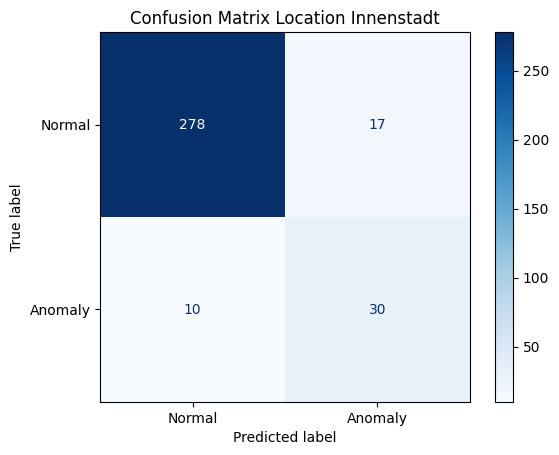

In [107]:


cm = confusion_matrix(true_vals,pred_vals)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix Location Innenstadt')
plt.savefig('confusion_matrix.png')
plt.show()

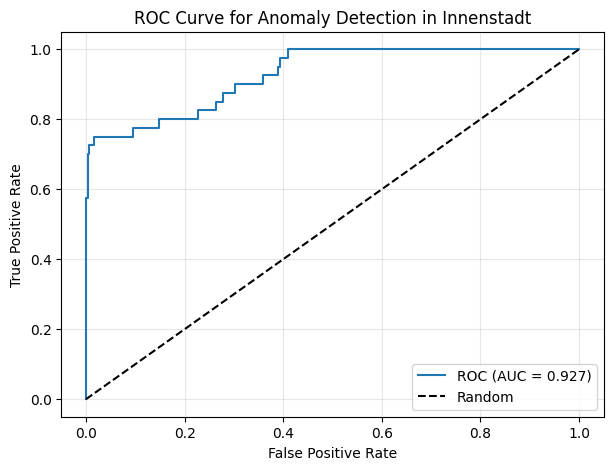

In [108]:
y_true = injected_data['anomaly']
y_score = point_results['point_error']
fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection in Innenstadt')
plt.legend()
plt.savefig('roc.png')
plt.grid(alpha=0.3)
plt.show()